# Этот ноутбук содержит честный ML-эксперимент по сравнению моделей:
- Дерево решений (Decision Tree)
- Random Forest
- Gradient Boosting
- Stacking (опционально)

# Анализируются два датасета:
1. **S06-hw-dataset-02.csv** - сложная бинарная классификация
2. **S06-hw-dataset-04.csv** - бинарная классификация с сильным дисбалансом

# 1. Импорт библиотек и настройки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Sklearn импорты
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, average_precision_score, RocCurveDisplay
)

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    StackingClassifier
)

# Утилиты
from sklearn.inspection import permutation_importance

# Настройки
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Создание директорий для артефактов
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
(ARTIFACTS_DIR / "figures").mkdir(exist_ok=True)

# Стиль графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 2. Вспомогательные функции

In [2]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Визуализация матрицы ошибок"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    plt.title(title)
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "figures" / f"confusion_matrix_{title.replace(' ', '_')}.png", dpi=300)
    plt.show()

def plot_roc_curve(model, X_test, y_test, title="ROC Curve"):
    """Визуализация ROC-кривой"""
    if hasattr(model, 'predict_proba'):
        RocCurveDisplay.from_estimator(model, X_test, y_test)
        plt.title(title)
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.legend()
        plt.grid(True)
        plt.savefig(ARTIFACTS_DIR / "figures" / f"roc_curve_{title.replace(' ', '_')}.png", dpi=300)
        plt.show()

def plot_pr_curve(model, X_test, y_test, title="Precision-Recall Curve"):
    """Визуализация PR-кривой (для дисбалансированных данных)"""
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        avg_precision = average_precision_score(y_test, y_proba)
        
        plt.figure(figsize=(8, 6))
        plt.plot(recall, precision, lw=2, label=f'AP = {avg_precision:.3f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.savefig(ARTIFACTS_DIR / "figures" / f"pr_curve_{title.replace(' ', '_')}.png", dpi=300)
        plt.show()

def plot_feature_importance(model, feature_names, title="Feature Importance", top_n=15):
    """Визуализация важности признаков"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[-top_n:][::-1]
        
        plt.figure(figsize=(10, 6))
        plt.bar(range(top_n), importances[indices])
        plt.xticks(range(top_n), [feature_names[i] for i in indices], rotation=45, ha='right')
        plt.title(title)
        plt.xlabel('Признаки')
        plt.ylabel('Важность')
        plt.tight_layout()
        plt.savefig(ARTIFACTS_DIR / "figures" / f"feature_importance_{title.replace(' ', '_')}.png", dpi=300)
        plt.show()
        
        return indices, importances[indices]
    return None, None

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name=""):
    """Полная оценка модели"""
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказания
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Вероятности (если есть)
    y_proba_train = y_proba_test = None
    if hasattr(model, 'predict_proba'):
        y_proba_train = model.predict_proba(X_train)[:, 1]
        y_proba_test = model.predict_proba(X_test)[:, 1]
    
    # Метрики
    metrics = {
        'model': model_name,
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'test_accuracy': accuracy_score(y_test, y_pred_test),
        'train_f1': f1_score(y_train, y_pred_train),
        'test_f1': f1_score(y_test, y_pred_test),
    }
    
    if y_proba_test is not None:
        metrics['test_roc_auc'] = roc_auc_score(y_test, y_proba_test)
        metrics['test_avg_precision'] = average_precision_score(y_test, y_proba_test)
    
    # Вывод результатов
    print(f"\n{'='*60}")
    print(f"Результаты для {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy на train: {metrics['train_accuracy']:.4f}")
    print(f"Accuracy на test:  {metrics['test_accuracy']:.4f}")
    print(f"F1 на train: {metrics['train_f1']:.4f}")
    print(f"F1 на test:  {metrics['test_f1']:.4f}")
    
    if 'test_roc_auc' in metrics:
        print(f"ROC-AUC на test: {metrics['test_roc_auc']:.4f}")
        print(f"Avg Precision на test: {metrics['test_avg_precision']:.4f}")
    
    # Матрица ошибок
    plot_confusion_matrix(y_test, y_pred_test, title=f"Confusion Matrix - {model_name}")
    
    # ROC-кривая
    plot_roc_curve(model, X_test, y_test, title=f"ROC Curve - {model_name}")
    
    return metrics, model

def run_grid_search(model, param_grid, X_train, y_train, cv=5, scoring='roc_auc'):
    """Запуск GridSearchCV"""
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший {scoring} score на CV: {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

# 3. Анализ датасета 02: Сложная бинарная классификация

АНАЛИЗ ДАТАСЕТА 02: Сложная бинарная классификация
Размер датасета: (18000, 39)

Первые 5 строк:
   id       f01       f02       f03        f04       f05       f06       f07  \
0   1 -0.149235 -2.826966 -0.522901  -4.198449  1.364943  0.815043 -1.195518   
1   2 -1.966180 -4.877542  0.268367  -9.607791  0.097149  1.347185 -3.872575   
2   3 -0.555964 -0.999920  0.209673 -14.119498 -1.808950 -0.006222 -4.651108   
3   4 -2.049199 -5.600713 -1.664677  -6.263893 -5.224455  0.848351  1.407210   
4   5 -0.220556  4.889479 -2.235840   6.450046  0.774389 -2.382625  2.584816   

        f08       f09  ...       f29       f30       f31       f32       f33  \
0 -1.932232  2.396353  ... -0.159323  0.448015  0.572745  0.149916  0.878392   
1 -0.395117  1.710068  ... -0.389212  1.383794  0.169876  0.043969 -0.963545   
2  0.911944 -0.289037  ... -1.383970  3.044321 -0.182864  1.425649 -8.418598   
3 -0.542080  0.119102  ... -2.713080  2.762637 -0.520796 -0.142455  1.668338   
4  4.211856 -0.317889 

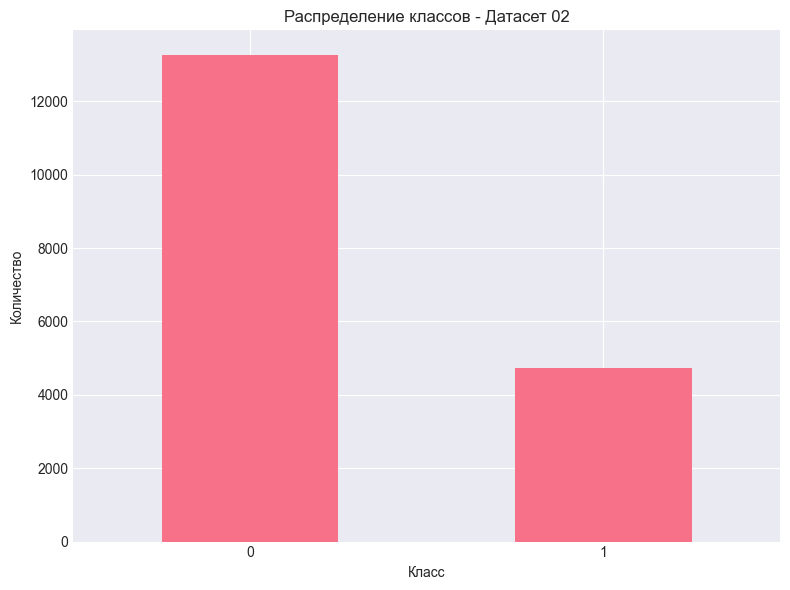


Пропуски в данных:
0

Количество признаков: 38
Имена признаков: ['id', 'f01', 'f02', 'f03', 'f04']...

Разделение для датасета 02:
Train размер: (13500, 38)
Test размер:  (4500, 38)


In [3]:
# Загрузка датасета 02
print("="*60)
print("АНАЛИЗ ДАТАСЕТА 02: Сложная бинарная классификация")
print("="*60)

df_02 = pd.read_csv("S06-hw-dataset-02.csv")
print(f"Размер датасета: {df_02.shape}")
print(f"\nПервые 5 строк:")
print(df_02.head())
print(f"\nИнформация о данных:")
print(df_02.info())
print(f"\nБазовая статистика:")
print(df_02.describe())

# Анализ целевой переменной
print(f"\nРаспределение целевой переменной:")
print(df_02['target'].value_counts())
print(f"\nДоли классов:")
print(df_02['target'].value_counts(normalize=True))

plt.figure(figsize=(8, 6))
df_02['target'].value_counts().plot(kind='bar')
plt.title('Распределение классов - Датасет 02')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "class_distribution_02.png", dpi=300)
plt.show()

# Проверка на пропуски
print(f"\nПропуски в данных:")
print(df_02.isnull().sum().sum())

# Подготовка данных для датасета 02
X_02 = df_02.drop('target', axis=1)
y_02 = df_02['target']
feature_names_02 = X_02.columns.tolist()

print(f"\nКоличество признаков: {X_02.shape[1]}")
print(f"Имена признаков: {feature_names_02[:5]}...")

# Разделение на train/test для датасета 02
X_train_02, X_test_02, y_train_02, y_test_02 = train_test_split(
    X_02, y_02, 
    test_size=0.25, 
    random_state=RANDOM_STATE, 
    stratify=y_02
)

print(f"\nРазделение для датасета 02:")
print(f"Train размер: {X_train_02.shape}")
print(f"Test размер:  {X_test_02.shape}")

# 4. Baseline модели для датасета 02

BASELINE МОДЕЛИ - ДАТАСЕТ 02

Результаты для Dummy Classifier (Dataset 02)
Accuracy на train: 0.7374
Accuracy на test:  0.7373
F1 на train: 0.0000
F1 на test:  0.0000
ROC-AUC на test: 0.5000
Avg Precision на test: 0.2627


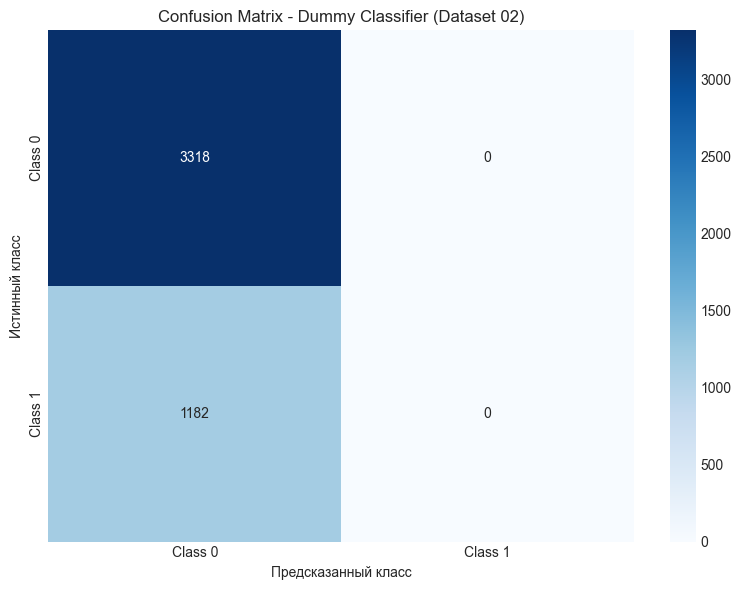

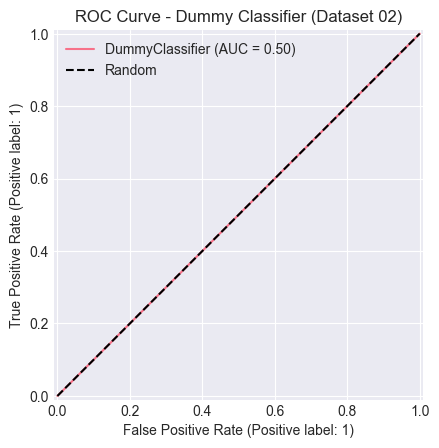


Результаты для Logistic Regression (Dataset 02)
Accuracy на train: 0.8159
Accuracy на test:  0.8160
F1 на train: 0.5671
F1 на test:  0.5714
ROC-AUC на test: 0.8009
Avg Precision на test: 0.6597


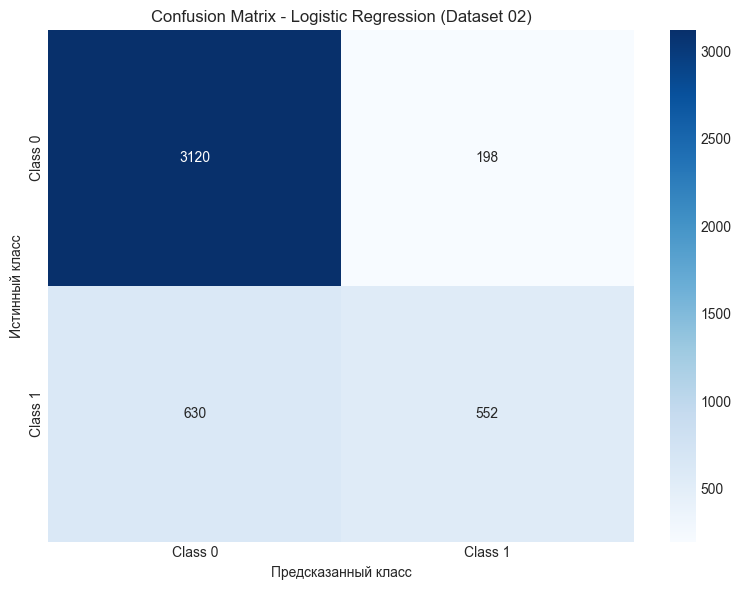

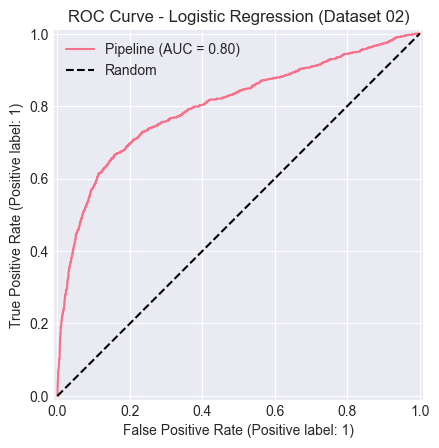

In [4]:
print("="*60)
print("BASELINE МОДЕЛИ - ДАТАСЕТ 02")
print("="*60)

# Dummy Classifier
dummy_02 = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_metrics_02, dummy_model_02 = evaluate_model(
    dummy_02, X_train_02, y_train_02, X_test_02, y_test_02, 
    "Dummy Classifier (Dataset 02)"
)

# Logistic Regression
lr_pipeline_02 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_metrics_02, lr_model_02 = evaluate_model(
    lr_pipeline_02, X_train_02, y_train_02, X_test_02, y_test_02,
    "Logistic Regression (Dataset 02)"
)

# Сохраняем baseline метрики
baseline_metrics_02 = [dummy_metrics_02, lr_metrics_02]

# 5. Модели недели 6 для датасета 02

In [5]:
print("="*60)
print("МОДЕЛИ НЕДЕЛИ 6 - ДАТАСЕТ 02")
print("="*60)

# Список для хранения всех метрик
all_metrics_02 = baseline_metrics_02.copy()
best_models_02 = {}

МОДЕЛИ НЕДЕЛИ 6 - ДАТАСЕТ 02


# 5.1. Decision Tree для датасета 02


Decision Tree Classifier (Dataset 02)
Подбор гиперпараметров для Decision Tree...
Лучшие параметры: {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Лучший roc_auc score на CV: 0.8349

Результаты для Decision Tree (Dataset 02)
Accuracy на train: 0.8667
Accuracy на test:  0.8187
F1 на train: 0.7226
F1 на test:  0.6205
ROC-AUC на test: 0.8289
Avg Precision на test: 0.6795


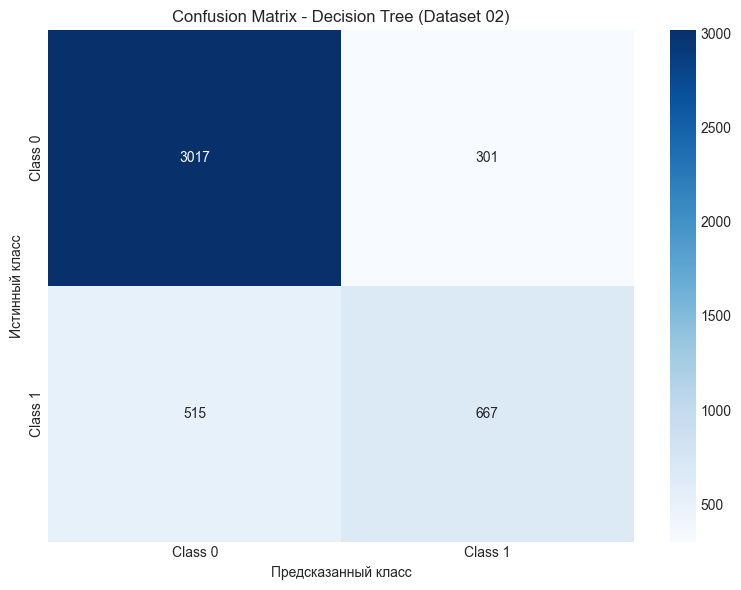

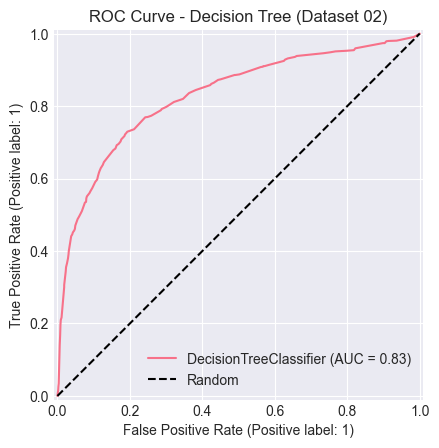

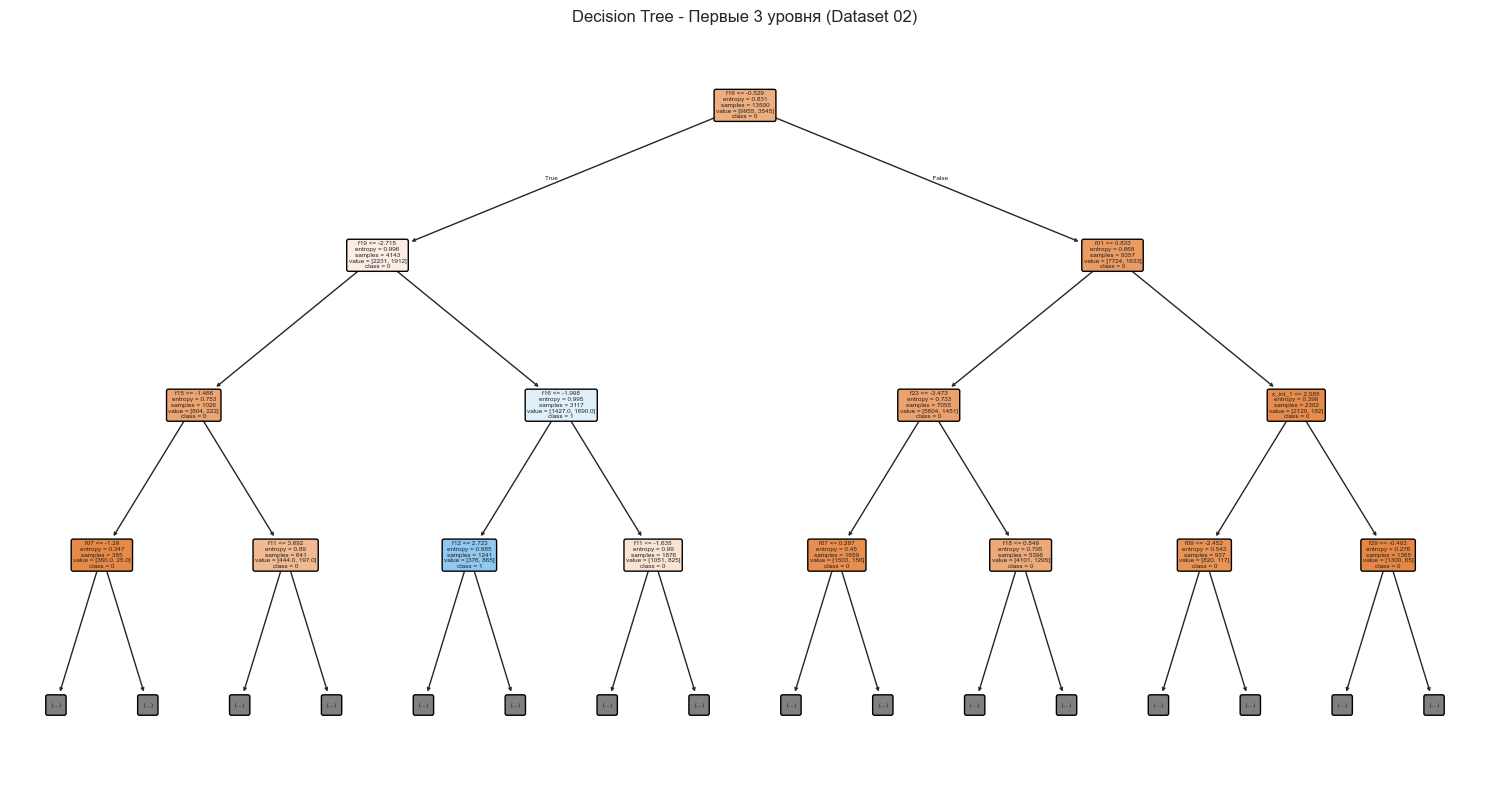

In [6]:
print("\n" + "="*60)
print("Decision Tree Classifier (Dataset 02)")
print("="*60)

# Определение сетки параметров для Decision Tree
dt_param_grid_02 = {
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10],
    'ccp_alpha': [0.0, 0.001, 0.01],
    'criterion': ['gini', 'entropy']
}

# Создание модели
dt_02 = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Подбор параметров
print("Подбор гиперпараметров для Decision Tree...")
best_dt_02, best_dt_params_02, best_dt_score_02 = run_grid_search(
    dt_02, dt_param_grid_02, X_train_02, y_train_02, cv=5, scoring='roc_auc'
)

# Оценка лучшей модели
dt_metrics_02, dt_model_02 = evaluate_model(
    best_dt_02, X_train_02, y_train_02, X_test_02, y_test_02,
    f"Decision Tree (Dataset 02)"
)

all_metrics_02.append(dt_metrics_02)
best_models_02['DecisionTree'] = dt_model_02

# Визуализация дерева (первые 3 уровня)
plt.figure(figsize=(15, 8))
from sklearn.tree import plot_tree
plot_tree(dt_model_02, max_depth=3, feature_names=feature_names_02, 
          class_names=['0', '1'], filled=True, rounded=True)
plt.title("Decision Tree - Первые 3 уровня (Dataset 02)")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "decision_tree_02.png", dpi=300)
plt.show()


# 5.2. Random Forest для датасета 02


Random Forest Classifier (Dataset 02)
Подбор гиперпараметров для Random Forest...
Лучшие параметры: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Лучший roc_auc score на CV: 0.9285

Результаты для Random Forest (Dataset 02)
Accuracy на train: 1.0000
Accuracy на test:  0.9002
F1 на train: 1.0000
F1 на test:  0.7817
ROC-AUC на test: 0.9307
Avg Precision на test: 0.8785


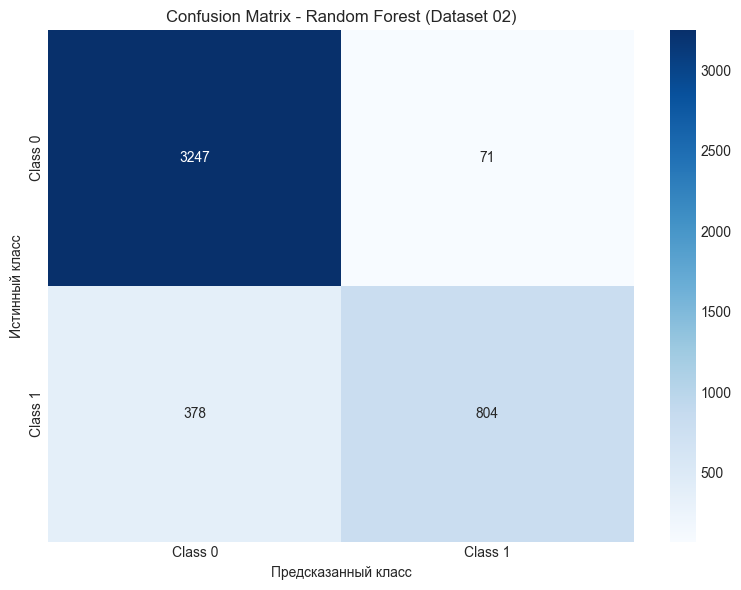

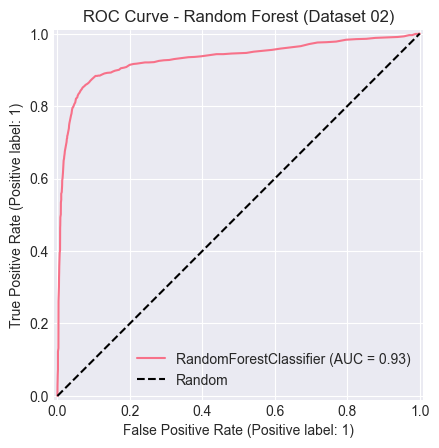

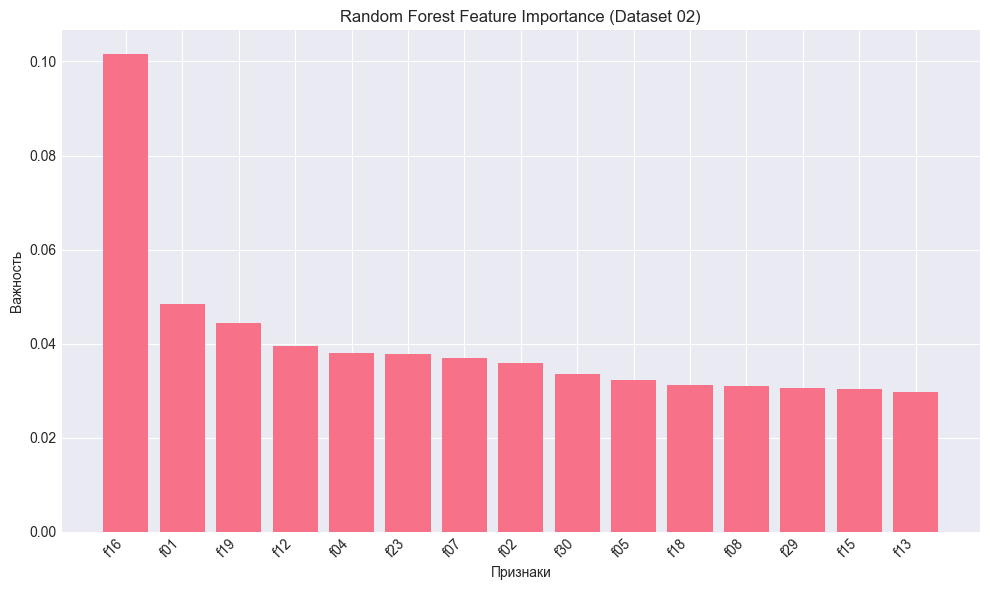

In [7]:
print("\n" + "="*60)
print("Random Forest Classifier (Dataset 02)")
print("="*60)

# Определение сетки параметров для Random Forest
rf_param_grid_02 = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True, False]
}

# Создание модели
rf_02 = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# Подбор параметров
print("Подбор гиперпараметров для Random Forest...")
best_rf_02, best_rf_params_02, best_rf_score_02 = run_grid_search(
    rf_02, rf_param_grid_02, X_train_02, y_train_02, cv=3, scoring='roc_auc'
)

# Оценка лучшей модели
rf_metrics_02, rf_model_02 = evaluate_model(
    best_rf_02, X_train_02, y_train_02, X_test_02, y_test_02,
    f"Random Forest (Dataset 02)"
)

all_metrics_02.append(rf_metrics_02)
best_models_02['RandomForest'] = rf_model_02

# Важность признаков
feature_importance_idx_02, feature_importance_vals_02 = plot_feature_importance(
    rf_model_02, feature_names_02, 
    title="Random Forest Feature Importance (Dataset 02)"
)

# 5.3. Gradient Boosting для датасета 02


Gradient Boosting Classifier (Dataset 02)
Подбор гиперпараметров для Gradient Boosting...
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.8}
Лучший roc_auc score на CV: 0.9301

Результаты для Gradient Boosting (Dataset 02)
Accuracy на train: 0.9793
Accuracy на test:  0.9093
F1 на train: 0.9597
F1 на test:  0.8106
ROC-AUC на test: 0.9314
Avg Precision на test: 0.8812


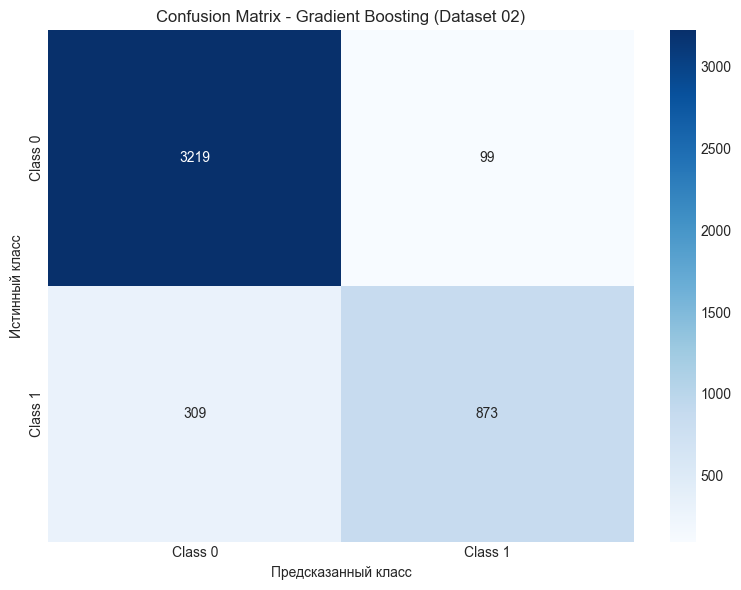

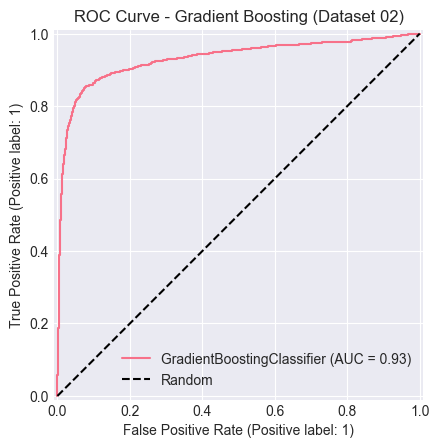

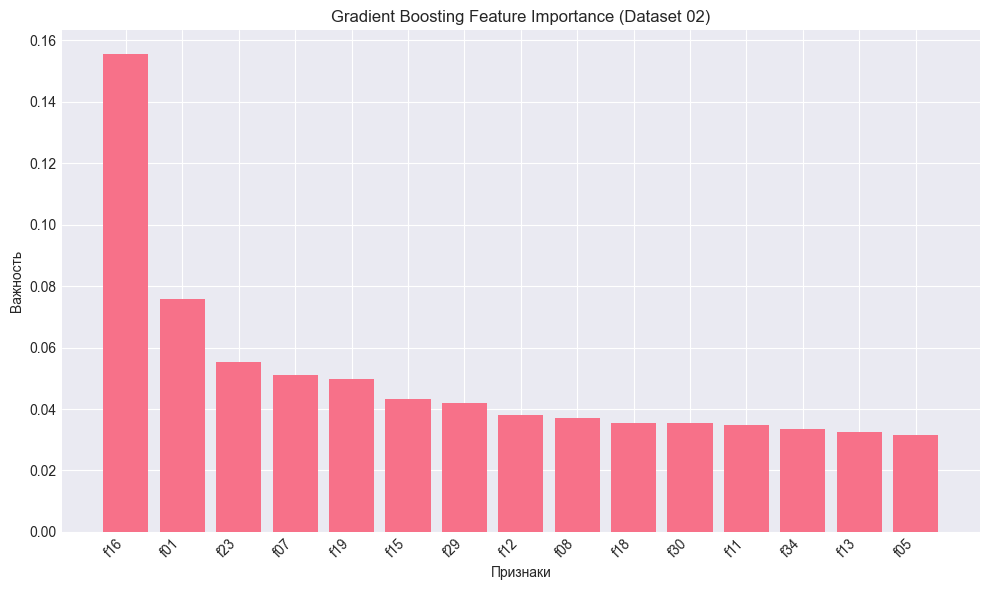

In [8]:
print("\n" + "="*60)
print("Gradient Boosting Classifier (Dataset 02)")
print("="*60)

# Определение сетки параметров для Gradient Boosting
gb_param_grid_02 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 5, 10],
    'subsample': [0.8, 1.0]
}

# Создание модели
gb_02 = GradientBoostingClassifier(random_state=RANDOM_STATE)

# Подбор параметров
print("Подбор гиперпараметров для Gradient Boosting...")
best_gb_02, best_gb_params_02, best_gb_score_02 = run_grid_search(
    gb_02, gb_param_grid_02, X_train_02, y_train_02, cv=3, scoring='roc_auc'
)

# Оценка лучшей модели
gb_metrics_02, gb_model_02 = evaluate_model(
    best_gb_02, X_train_02, y_train_02, X_test_02, y_test_02,
    f"Gradient Boosting (Dataset 02)"
)

all_metrics_02.append(gb_metrics_02)
best_models_02['GradientBoosting'] = gb_model_02

# Важность признаков для Gradient Boosting
feature_importance_idx_gb_02, feature_importance_vals_gb_02 = plot_feature_importance(
    gb_model_02, feature_names_02,
    title="Gradient Boosting Feature Importance (Dataset 02)"
)

# 5.4. Stacking Classifier для датасета 02


Stacking Classifier (Dataset 02)

Результаты для Stacking Classifier (Dataset 02)
Accuracy на train: 1.0000
Accuracy на test:  0.9153
F1 на train: 1.0000
F1 на test:  0.8291
ROC-AUC на test: 0.9340
Avg Precision на test: 0.8815


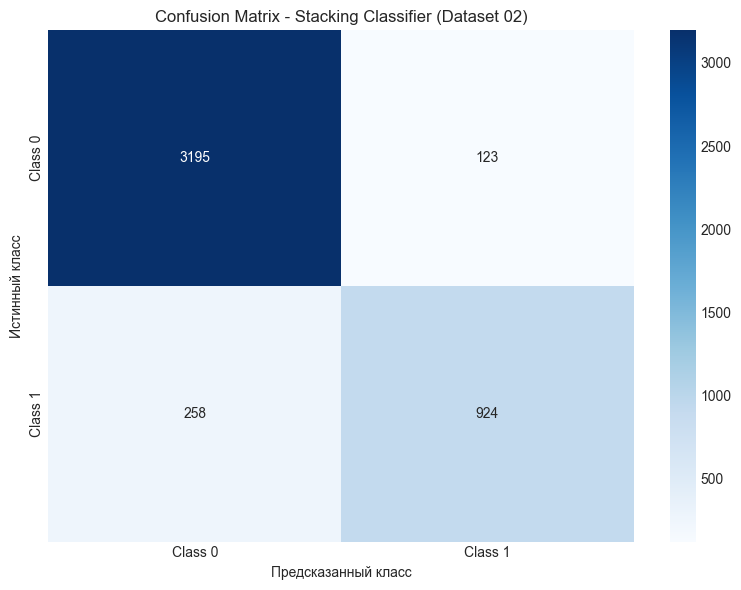

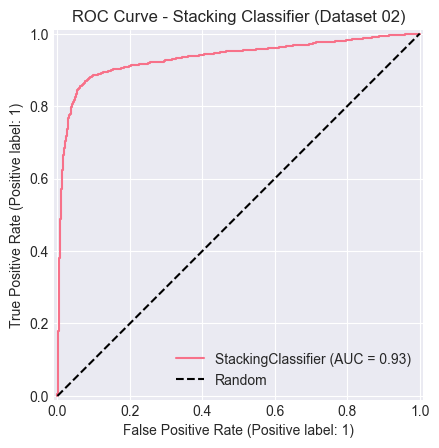

In [9]:
print("\n" + "="*60)
print("Stacking Classifier (Dataset 02)")
print("="*60)

# Создание стекинга из лучших моделей
estimators_02 = [
    ('lr', lr_model_02),
    ('rf', rf_model_02),
    ('gb', gb_model_02)
]

stacking_02 = StackingClassifier(
    estimators=estimators_02,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    cv=5,
    n_jobs=-1
)

# Оценка модели стекинга
stacking_metrics_02, stacking_model_02 = evaluate_model(
    stacking_02, X_train_02, y_train_02, X_test_02, y_test_02,
    "Stacking Classifier (Dataset 02)"
)

all_metrics_02.append(stacking_metrics_02)
best_models_02['Stacking'] = stacking_model_02

# 6. Сводка результатов для датасета 02

СВОДКА РЕЗУЛЬТАТОВ - ДАТАСЕТ 02

Результаты всех моделей (Dataset 02):
                              model  test_accuracy   test_f1  test_roc_auc  accuracy_diff
0     Dummy Classifier (Dataset 02)       0.737333  0.000000      0.500000       0.000074
1  Logistic Regression (Dataset 02)       0.816000  0.571429      0.800884      -0.000074
2        Decision Tree (Dataset 02)       0.818667  0.620465      0.828914       0.048074
3        Random Forest (Dataset 02)       0.900222  0.781721      0.930707       0.099778
4    Gradient Boosting (Dataset 02)       0.909333  0.810585      0.931447       0.070000
5  Stacking Classifier (Dataset 02)       0.915333  0.829071      0.934011       0.084667

Лучшая модель по ROC-AUC: Stacking Classifier (Dataset 02)
ROC-AUC лучшей модели: 0.9340


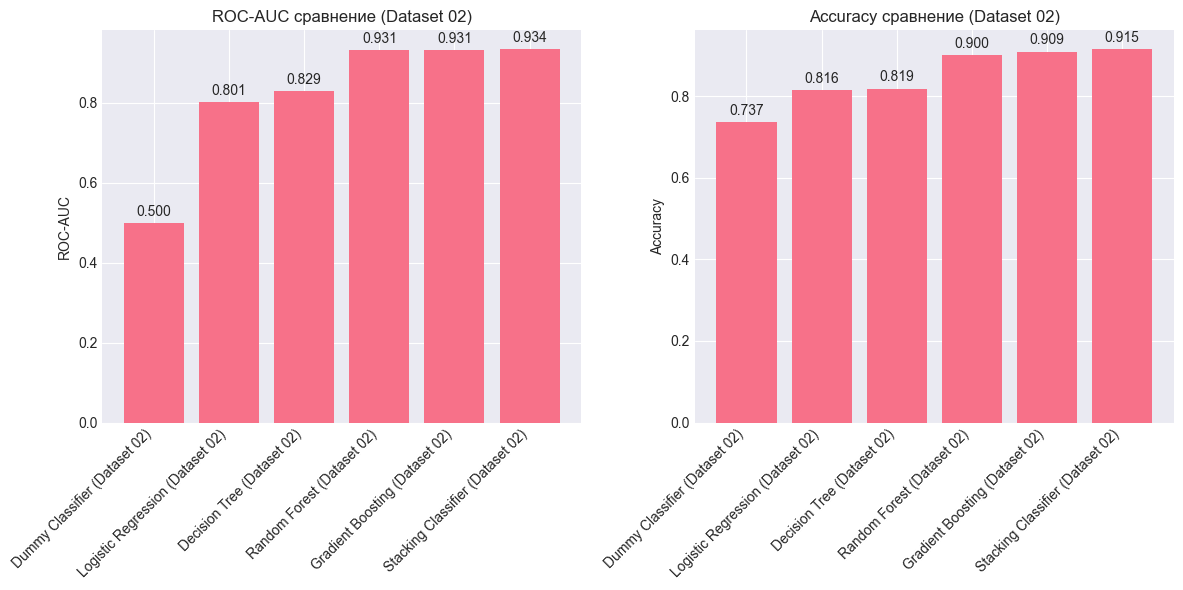

In [10]:
print("="*60)
print("СВОДКА РЕЗУЛЬТАТОВ - ДАТАСЕТ 02")
print("="*60)

# Создание DataFrame с результатами
results_df_02 = pd.DataFrame(all_metrics_02)

# Добавление информации о переобучении
results_df_02['accuracy_diff'] = results_df_02['train_accuracy'] - results_df_02['test_accuracy']
results_df_02['f1_diff'] = results_df_02['train_f1'] - results_df_02['test_f1']

print("\nРезультаты всех моделей (Dataset 02):")
print(results_df_02[['model', 'test_accuracy', 'test_f1', 'test_roc_auc', 'accuracy_diff']].to_string())

# Определение лучшей модели по ROC-AUC
if 'test_roc_auc' in results_df_02.columns:
    best_model_idx_02 = results_df_02['test_roc_auc'].idxmax()
    best_model_02 = results_df_02.loc[best_model_idx_02, 'model']
    print(f"\nЛучшая модель по ROC-AUC: {best_model_02}")
    print(f"ROC-AUC лучшей модели: {results_df_02.loc[best_model_idx_02, 'test_roc_auc']:.4f}")

# Визуализация сравнения моделей
plt.figure(figsize=(12, 6))
models_to_plot = results_df_02['model'].tolist()
x_pos = np.arange(len(models_to_plot))

# ROC-AUC сравнение
if 'test_roc_auc' in results_df_02.columns:
    plt.subplot(1, 2, 1)
    bars = plt.bar(x_pos, results_df_02['test_roc_auc'])
    plt.xticks(x_pos, models_to_plot, rotation=45, ha='right')
    plt.title('ROC-AUC сравнение (Dataset 02)')
    plt.ylabel('ROC-AUC')
    
    # Добавление значений на столбцы
    for bar, val in zip(bars, results_df_02['test_roc_auc']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom')

# Accuracy сравнение
plt.subplot(1, 2, 2)
bars = plt.bar(x_pos, results_df_02['test_accuracy'])
plt.xticks(x_pos, models_to_plot, rotation=45, ha='right')
plt.title('Accuracy сравнение (Dataset 02)')
plt.ylabel('Accuracy')

# Добавление значений на столбцы
for bar, val in zip(bars, results_df_02['test_accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "model_comparison_02.png", dpi=300)
plt.show()

# 7. Permutation Importance для лучшей модели (Dataset 02)

PERMUTATION IMPORTANCE - ДАТАСЕТ 02
Анализ важности признаков для модели: Stacking Classifier (Dataset 02)


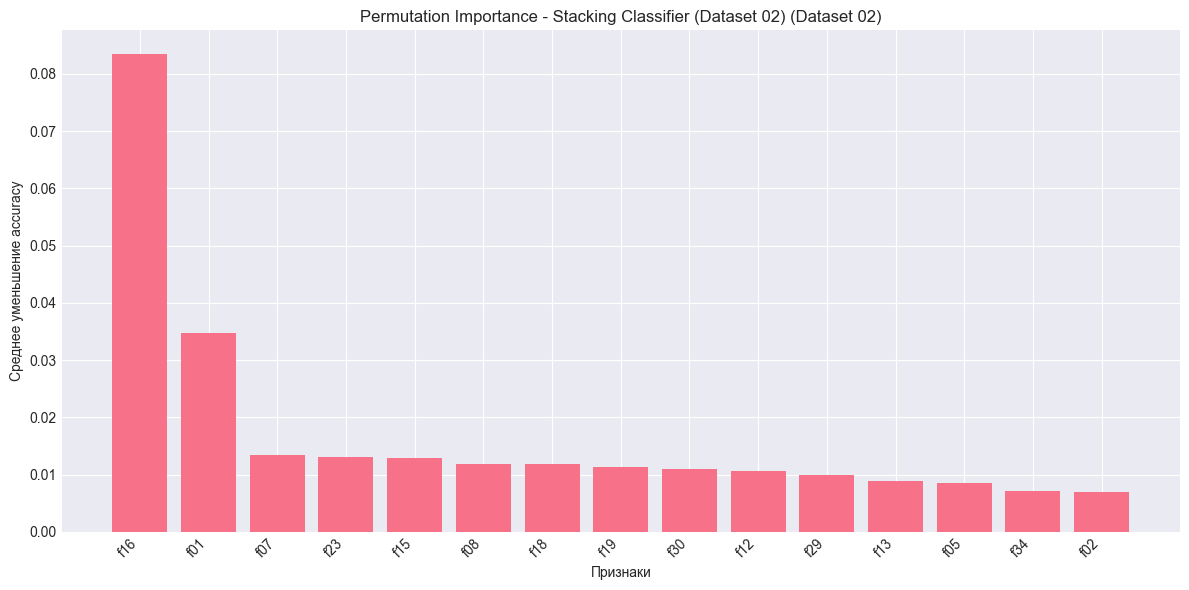

In [11]:
print("="*60)
print("PERMUTATION IMPORTANCE - ДАТАСЕТ 02")
print("="*60)

# Выбор лучшей модели для анализа
if 'test_roc_auc' in results_df_02.columns:
    best_model_name_02 = results_df_02.loc[results_df_02['test_roc_auc'].idxmax(), 'model']
else:
    best_model_name_02 = results_df_02.loc[results_df_02['test_accuracy'].idxmax(), 'model']

best_model_for_importance_02 = best_models_02.get(best_model_name_02.split(' ')[0], gb_model_02)

print(f"Анализ важности признаков для модели: {best_model_name_02}")

# Вычисление permutation importance
if best_model_for_importance_02 is not None:
    perm_importance_02 = permutation_importance(
        best_model_for_importance_02, X_test_02, y_test_02,
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    
    # Сортировка по важности
    sorted_idx_02 = perm_importance_02.importances_mean.argsort()[::-1]
    
    # Визуализация top-15 признаков
    plt.figure(figsize=(12, 6))
    top_n = min(15, len(feature_names_02))
    plt.bar(range(top_n), perm_importance_02.importances_mean[sorted_idx_02][:top_n])
    plt.xticks(range(top_n), [feature_names_02[i] for i in sorted_idx_02[:top_n]], rotation=45, ha='right')
    plt.title(f'Permutation Importance - {best_model_name_02} (Dataset 02)')
    plt.xlabel('Признаки')
    plt.ylabel('Среднее уменьшение accuracy')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "figures" / "permutation_importance_02.png", dpi=300)
    plt.show()
    
    # Сохранение результатов permutation importance
    perm_importance_dict_02 = {
        'model': best_model_name_02,
        'top_features': [
            {
                'feature': feature_names_02[i],
                'importance': float(perm_importance_02.importances_mean[i]),
                'std': float(perm_importance_02.importances_std[i])
            }
            for i in sorted_idx_02[:top_n]
        ]
    }
    
    with open(ARTIFACTS_DIR / 'permutation_importance_02.json', 'w') as f:
        json.dump(perm_importance_dict_02, f, indent=2)


# 8. Анализ датасета 04: Дисбалансированная классификация


АНАЛИЗ ДАТАСЕТА 04: Дисбалансированная бинарная классификация
Размер датасета: (25000, 62)

Первые 5 строк:
   id       f01       f02       f03       f04       f05       f06       f07  \
0   1 -1.250210  1.423474 -0.225004 -4.023138 -0.832729 -0.550874  1.772090   
1   2  0.074328  0.376429  0.212831 -0.502074  2.017405  0.625496  1.943785   
2   3  0.638481  0.060968  0.746760  2.479653 -0.292858 -0.078139 -2.918423   
3   4  1.712916 -1.350969 -0.256473  1.622074 -0.445141  0.911932 -3.440345   
4   5  0.905676 -0.206545 -0.068806  4.086026 -1.010045 -0.772644 -4.207688   

        f08       f09  ...        f52        f53       f54       f55  \
0  2.761690 -0.698750  ...  10.938269   0.501178  1.600001  0.314212   
1  1.242030 -0.524090  ...   7.775262  -4.550195  6.272586 -0.932162   
2 -0.013186  1.009135  ...  -4.448447  -9.593179 -3.093519  0.029321   
3  1.505192 -1.104348  ...  -1.619072  -3.237479 -5.474038 -1.582475   
4  2.506104  1.589143  ...  -2.396844 -10.540129 -5.5328

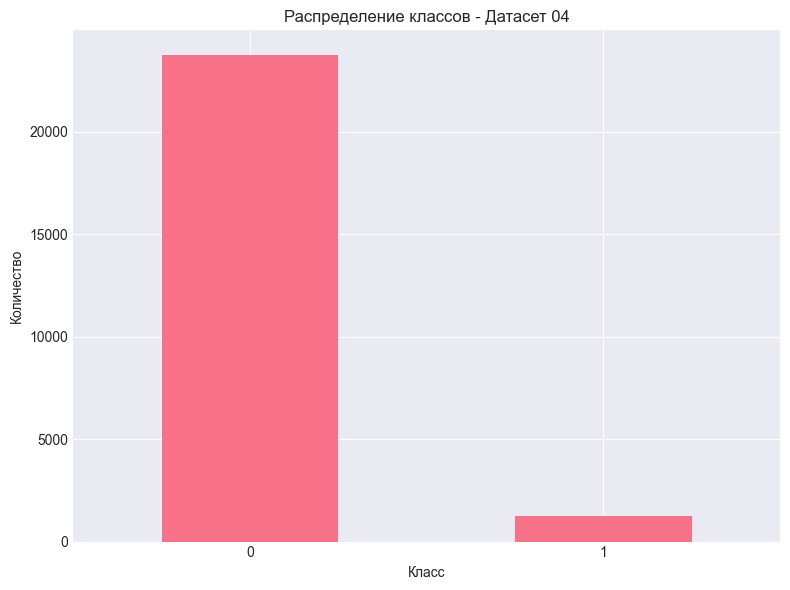


Пропуски в данных:
0

Количество признаков: 61
Имена признаков: ['id', 'f01', 'f02', 'f03', 'f04']...

Разделение для датасета 04:
Train размер: (18750, 61)
Test размер:  (6250, 61)


In [12]:
# Загрузка датасета 04
print("\n" + "="*60)
print("АНАЛИЗ ДАТАСЕТА 04: Дисбалансированная бинарная классификация")
print("="*60)

df_04 = pd.read_csv("S06-hw-dataset-04.csv")
print(f"Размер датасета: {df_04.shape}")
print(f"\nПервые 5 строк:")
print(df_04.head())
print(f"\nИнформация о данных:")
print(df_04.info())

# Анализ целевой переменной
print(f"\nРаспределение целевой переменной:")
print(df_04['target'].value_counts())
print(f"\nДоли классов:")
class_dist_04 = df_04['target'].value_counts(normalize=True)
print(class_dist_04)

plt.figure(figsize=(8, 6))
df_04['target'].value_counts().plot(kind='bar')
plt.title('Распределение классов - Датасет 04')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "class_distribution_04.png", dpi=300)
plt.show()

# Проверка на пропуски
print(f"\nПропуски в данных:")
print(df_04.isnull().sum().sum())

# Подготовка данных для датасета 04
X_04 = df_04.drop('target', axis=1)
y_04 = df_04['target']
feature_names_04 = X_04.columns.tolist()

print(f"\nКоличество признаков: {X_04.shape[1]}")
print(f"Имена признаков: {feature_names_04[:5]}...")

# Разделение на train/test для датасета 04
X_train_04, X_test_04, y_train_04, y_test_04 = train_test_split(
    X_04, y_04, 
    test_size=0.25, 
    random_state=RANDOM_STATE, 
    stratify=y_04
)

print(f"\nРазделение для датасета 04:")
print(f"Train размер: {X_train_04.shape}")
print(f"Test размер:  {X_test_04.shape}")


# 9. Baseline модели для датасета 04

BASELINE МОДЕЛИ - ДАТАСЕТ 04

Результаты для Dummy Classifier (Dataset 04)
Accuracy на train: 0.9508
Accuracy на test:  0.9509
F1 на train: 0.0000
F1 на test:  0.0000
ROC-AUC на test: 0.5000
Avg Precision на test: 0.0491


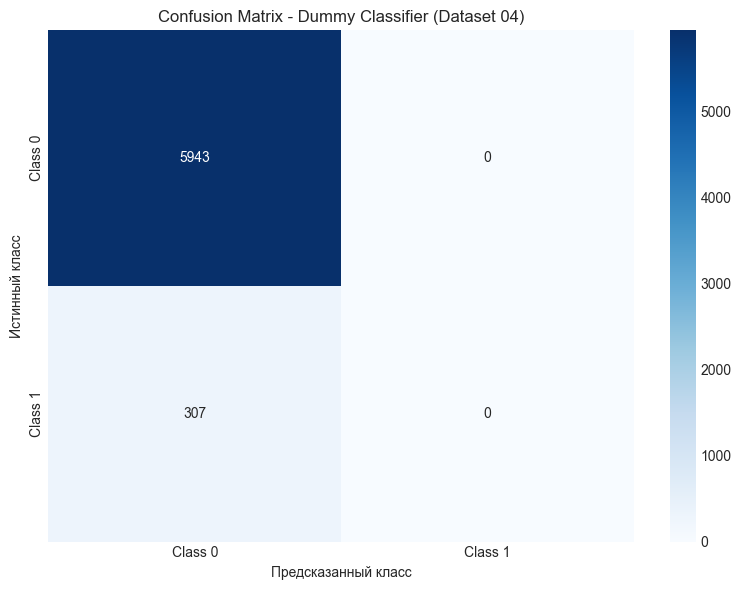

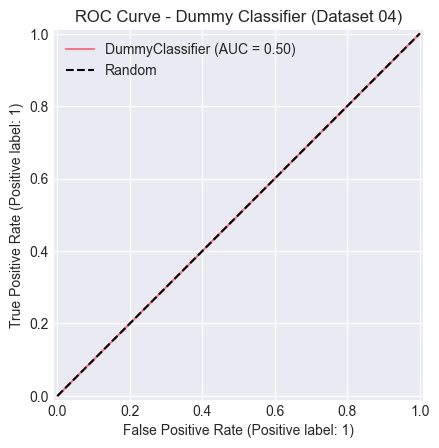


Результаты для Logistic Regression Balanced (Dataset 04)
Accuracy на train: 0.7878
Accuracy на test:  0.7787
F1 на train: 0.2550
F1 на test:  0.2576
ROC-AUC на test: 0.8418
Avg Precision на test: 0.4575


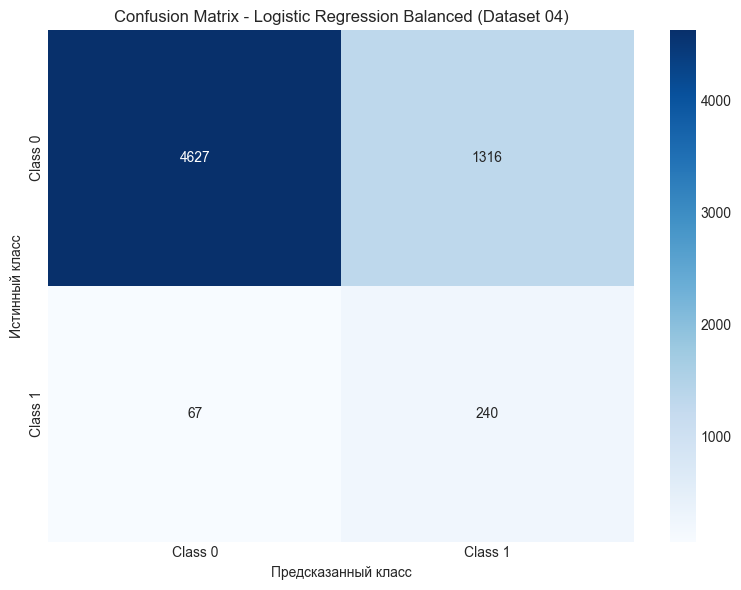

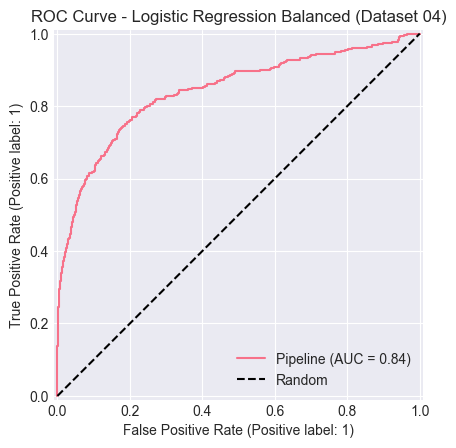

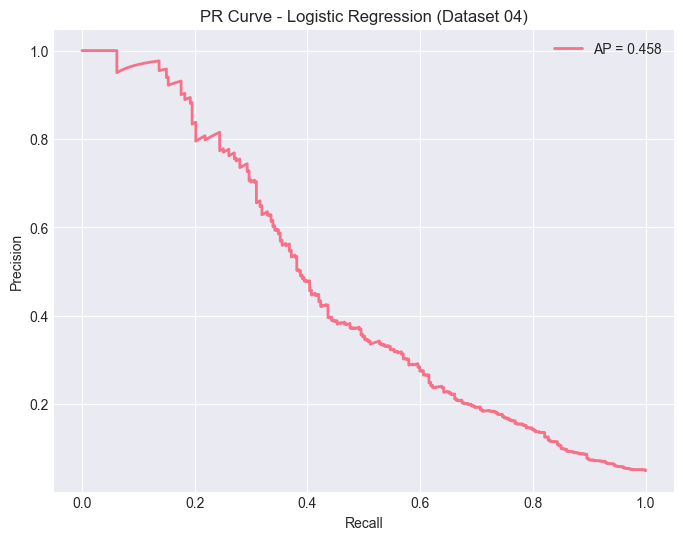

In [13]:
print("="*60)
print("BASELINE МОДЕЛИ - ДАТАСЕТ 04")
print("="*60)

# Dummy Classifier
dummy_04 = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_metrics_04, dummy_model_04 = evaluate_model(
    dummy_04, X_train_04, y_train_04, X_test_04, y_test_04, 
    "Dummy Classifier (Dataset 04)"
)

# Logistic Regression с учетом дисбаланса
lr_pipeline_04 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))
])

lr_metrics_04, lr_model_04 = evaluate_model(
    lr_pipeline_04, X_train_04, y_train_04, X_test_04, y_test_04,
    "Logistic Regression Balanced (Dataset 04)"
)

# PR-кривая для дисбалансированных данных
plot_pr_curve(lr_model_04, X_test_04, y_test_04, title="PR Curve - Logistic Regression (Dataset 04)")

# Сохраняем baseline метрики
baseline_metrics_04 = [dummy_metrics_04, lr_metrics_04]

# 10. Модели недели 6 для датасета 04

In [14]:
print("="*60)
print("МОДЕЛИ НЕДЕЛИ 6 - ДАТАСЕТ 04")
print("="*60)

# Список для хранения всех метрик
all_metrics_04 = baseline_metrics_04.copy()
best_models_04 = {}


МОДЕЛИ НЕДЕЛИ 6 - ДАТАСЕТ 04


# 10.1. Decision Tree для датасета 04 (с учетом дисбаланса)


Decision Tree Classifier (Dataset 04)
Подбор гиперпараметров для Decision Tree...
Лучшие параметры: {'ccp_alpha': 0.001, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Лучший average_precision score на CV: 0.5194

Результаты для Decision Tree (Dataset 04)
Accuracy на train: 0.9733
Accuracy на test:  0.9678
F1 на train: 0.6464
F1 на test:  0.5659
ROC-AUC на test: 0.8474
Avg Precision на test: 0.5572


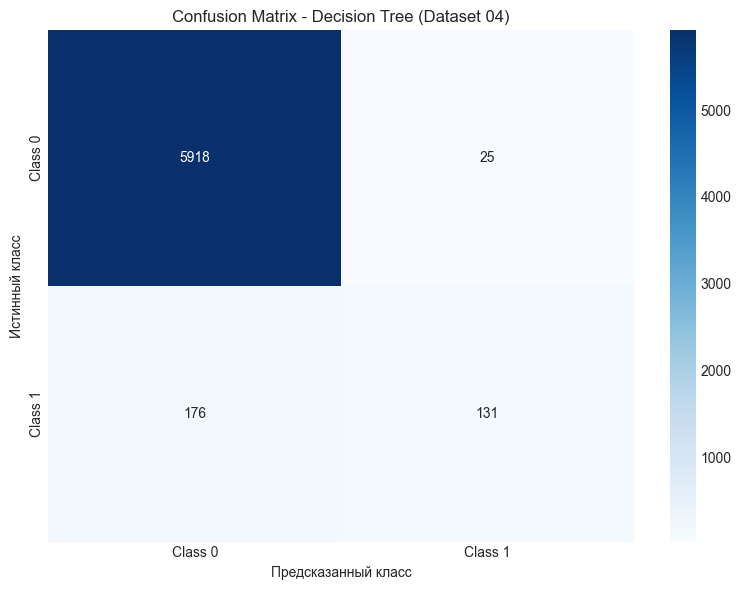

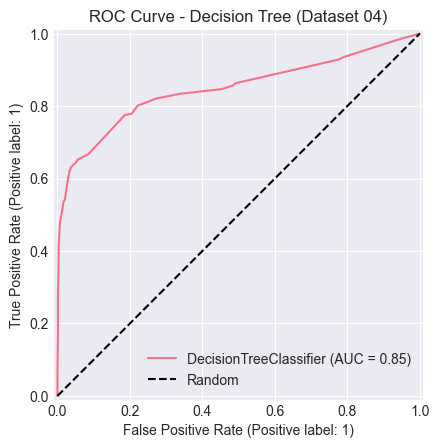

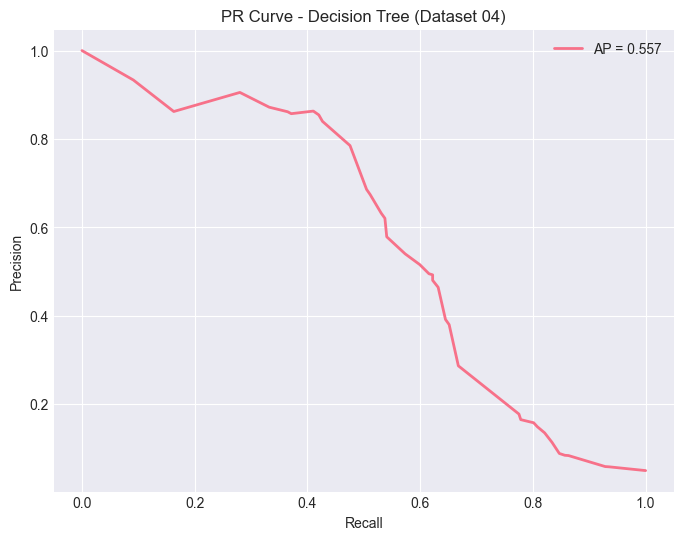

In [15]:
print("\n" + "="*60)
print("Decision Tree Classifier (Dataset 04)")
print("="*60)

# Определение сетки параметров для Decision Tree с учетом дисбаланса
dt_param_grid_04 = {
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

# Создание модели
dt_04 = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Подбор параметров с использованием average_precision для дисбалансированных данных
print("Подбор гиперпараметров для Decision Tree...")
best_dt_04, best_dt_params_04, best_dt_score_04 = run_grid_search(
    dt_04, dt_param_grid_04, X_train_04, y_train_04, cv=5, scoring='average_precision'
)

# Оценка лучшей модели
dt_metrics_04, dt_model_04 = evaluate_model(
    best_dt_04, X_train_04, y_train_04, X_test_04, y_test_04,
    f"Decision Tree (Dataset 04)"
)

all_metrics_04.append(dt_metrics_04)
best_models_04['DecisionTree'] = dt_model_04

# PR-кривая
plot_pr_curve(dt_model_04, X_test_04, y_test_04, title="PR Curve - Decision Tree (Dataset 04)")


Random Forest Classifier (Dataset 04)
Подбор гиперпараметров для Random Forest...
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Лучший average_precision score на CV: 0.7398

Результаты для Random Forest (Dataset 04)
Accuracy на train: 0.9996
Accuracy на test:  0.9757
F1 на train: 0.9962
F1 на test:  0.6724
ROC-AUC на test: 0.9105
Avg Precision на test: 0.7891


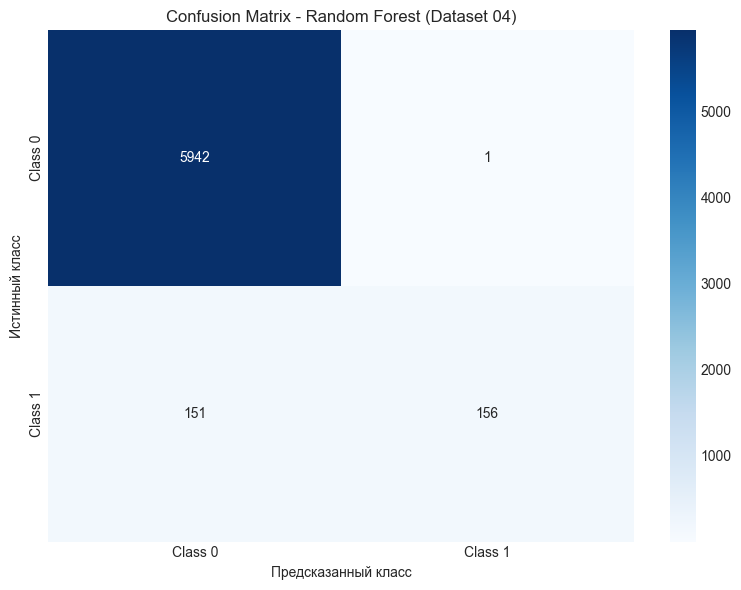

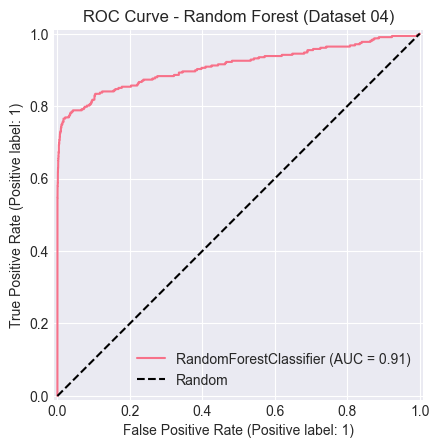

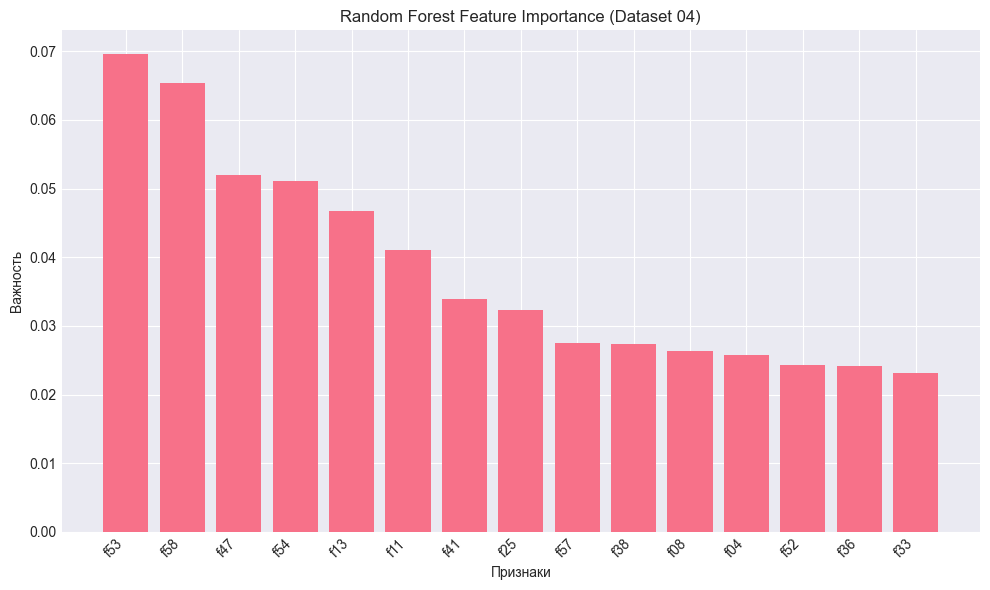

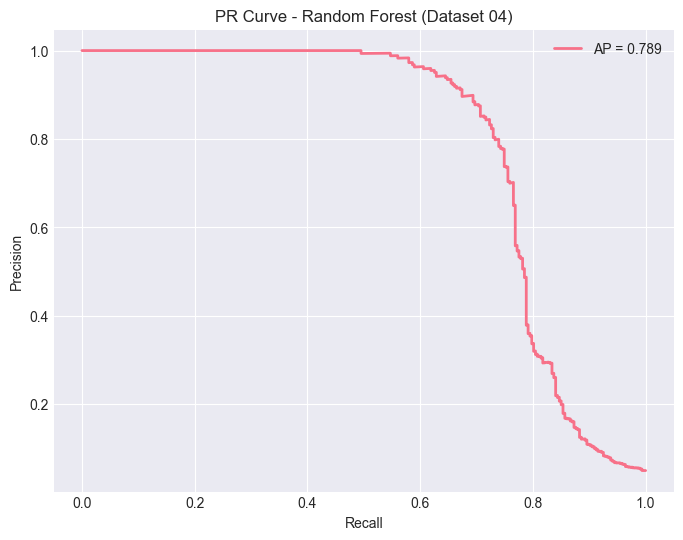

In [16]:
print("\n" + "="*60)
print("Random Forest Classifier (Dataset 04)")
print("="*60)

# Определение сетки параметров для Random Forest с учетом дисбаланса
rf_param_grid_04 = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

# Создание модели
rf_04 = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# Подбор параметров
print("Подбор гиперпараметров для Random Forest...")
best_rf_04, best_rf_params_04, best_rf_score_04 = run_grid_search(
    rf_04, rf_param_grid_04, X_train_04, y_train_04, cv=3, scoring='average_precision'
)

# Оценка лучшей модели
rf_metrics_04, rf_model_04 = evaluate_model(
    best_rf_04, X_train_04, y_train_04, X_test_04, y_test_04,
    f"Random Forest (Dataset 04)"
)

all_metrics_04.append(rf_metrics_04)
best_models_04['RandomForest'] = rf_model_04

# Важность признаков
feature_importance_idx_04, feature_importance_vals_04 = plot_feature_importance(
    rf_model_04, feature_names_04, 
    title="Random Forest Feature Importance (Dataset 04)"
)

# PR-кривая
plot_pr_curve(rf_model_04, X_test_04, y_test_04, title="PR Curve - Random Forest (Dataset 04)")

# 10.3. Gradient Boosting для датасета 04


Gradient Boosting Classifier (Dataset 04)
Подбор гиперпараметров для Gradient Boosting...
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 200, 'subsample': 0.8}
Лучший average_precision score на CV: 0.7462

Результаты для Gradient Boosting (Dataset 04)
Accuracy на train: 0.9869
Accuracy на test:  0.9802
F1 на train: 0.8477
F1 на test:  0.7500
ROC-AUC на test: 0.9004
Avg Precision на test: 0.7924


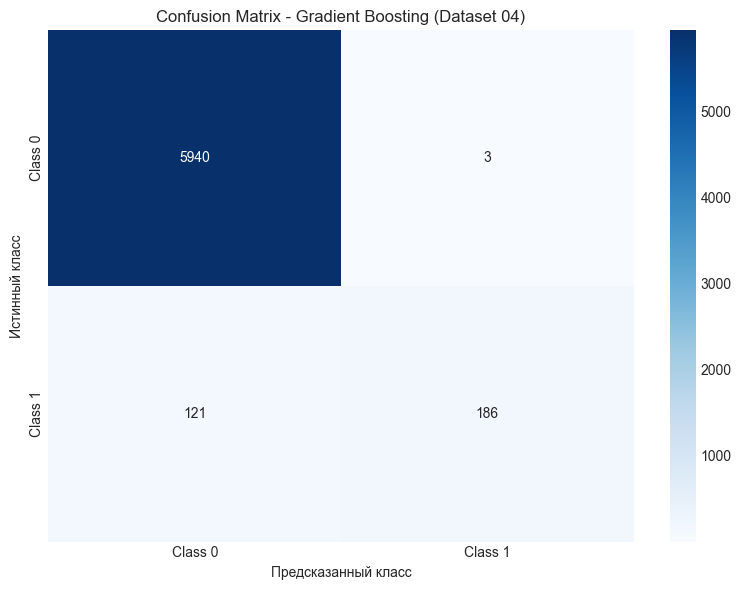

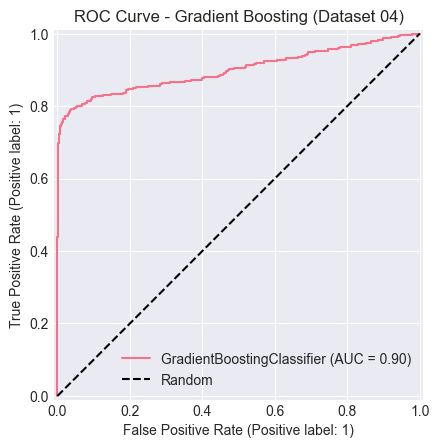

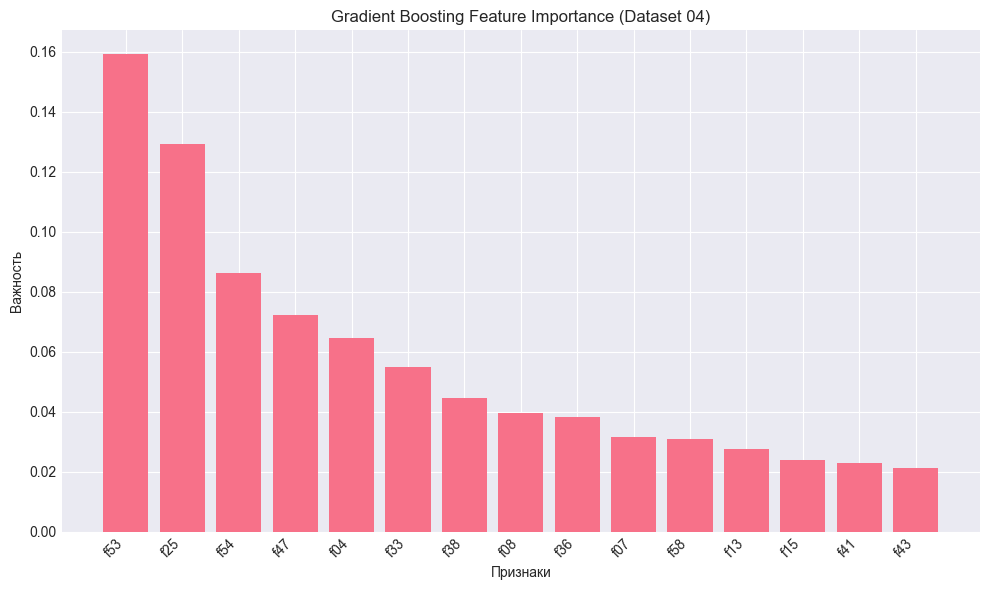

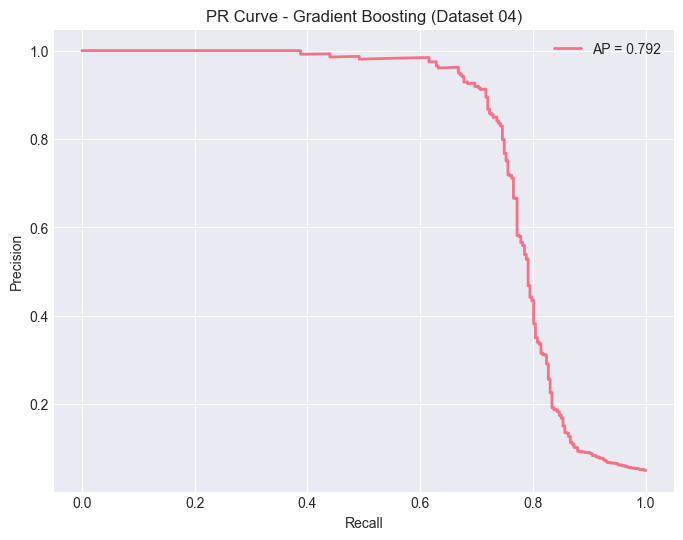

In [17]:
print("\n" + "="*60)
print("Gradient Boosting Classifier (Dataset 04)")
print("="*60)

# Определение сетки параметров для Gradient Boosting
gb_param_grid_04 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_leaf': [5, 10, 20],
    'subsample': [0.8, 1.0]
}

# Создание модели
gb_04 = GradientBoostingClassifier(random_state=RANDOM_STATE)

# Подбор параметров
print("Подбор гиперпараметров для Gradient Boosting...")
best_gb_04, best_gb_params_04, best_gb_score_04 = run_grid_search(
    gb_04, gb_param_grid_04, X_train_04, y_train_04, cv=3, scoring='average_precision'
)

# Оценка лучшей модели
gb_metrics_04, gb_model_04 = evaluate_model(
    best_gb_04, X_train_04, y_train_04, X_test_04, y_test_04,
    f"Gradient Boosting (Dataset 04)"
)

all_metrics_04.append(gb_metrics_04)
best_models_04['GradientBoosting'] = gb_model_04

# Важность признаков для Gradient Boosting
feature_importance_idx_gb_04, feature_importance_vals_gb_04 = plot_feature_importance(
    gb_model_04, feature_names_04,
    title="Gradient Boosting Feature Importance (Dataset 04)"
)

# PR-кривая
plot_pr_curve(gb_model_04, X_test_04, y_test_04, title="PR Curve - Gradient Boosting (Dataset 04)")

# 10.4. Stacking Classifier для датасета 04


Stacking Classifier (Dataset 04)

Результаты для Stacking Classifier (Dataset 04)
Accuracy на train: 0.9847
Accuracy на test:  0.9603
F1 на train: 0.8654
F1 на test:  0.6612
ROC-AUC на test: 0.9120
Avg Precision на test: 0.8018


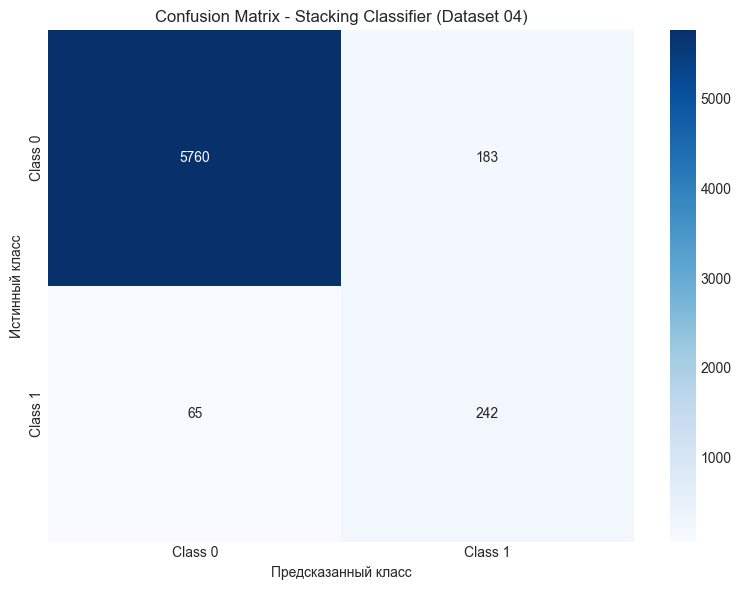

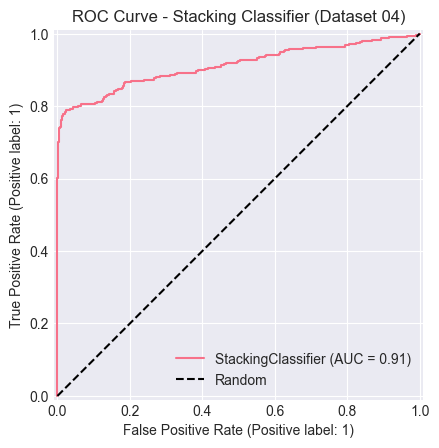

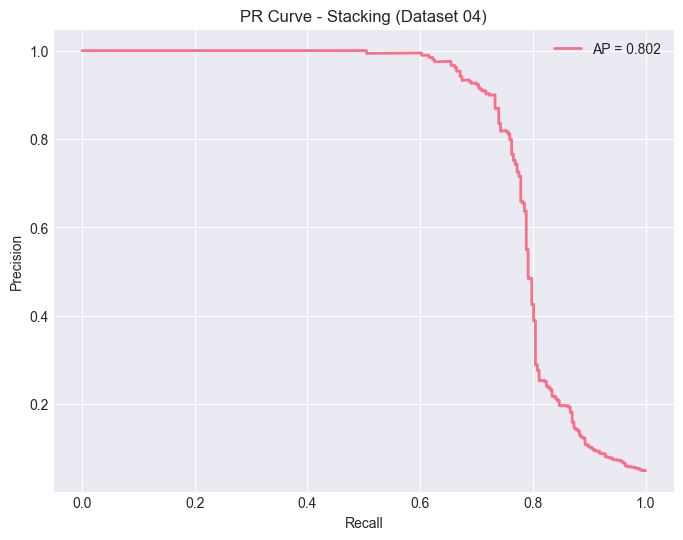

In [18]:
print("\n" + "="*60)
print("Stacking Classifier (Dataset 04)")
print("="*60)

# Создание стекинга из лучших моделей
estimators_04 = [
    ('lr', lr_model_04),
    ('rf', rf_model_04),
    ('gb', gb_model_04)
]

stacking_04 = StackingClassifier(
    estimators=estimators_04,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'),
    cv=5,
    n_jobs=-1
)

# Оценка модели стекинга
stacking_metrics_04, stacking_model_04 = evaluate_model(
    stacking_04, X_train_04, y_train_04, X_test_04, y_test_04,
    "Stacking Classifier (Dataset 04)"
)

all_metrics_04.append(stacking_metrics_04)
best_models_04['Stacking'] = stacking_model_04

# PR-кривая для стекинга
plot_pr_curve(stacking_model_04, X_test_04, y_test_04, title="PR Curve - Stacking (Dataset 04)")

# 11. Сводка результатов для датасета 04

СВОДКА РЕЗУЛЬТАТОВ - ДАТАСЕТ 04

Результаты всех моделей (Dataset 04):
                                       model  test_accuracy   test_f1  test_avg_precision  accuracy_diff
0              Dummy Classifier (Dataset 04)        0.95088  0.000000            0.049120      -0.000107
1  Logistic Regression Balanced (Dataset 04)        0.77872  0.257649            0.457518       0.009067
2                 Decision Tree (Dataset 04)        0.96784  0.565875            0.557213       0.005440
3                 Random Forest (Dataset 04)        0.97568  0.672414            0.789055       0.023947
4             Gradient Boosting (Dataset 04)        0.98016  0.750000            0.792415       0.006773
5           Stacking Classifier (Dataset 04)        0.96032  0.661202            0.801757       0.024373

Лучшая модель по Average Precision: Stacking Classifier (Dataset 04)
Average Precision лучшей модели: 0.8018


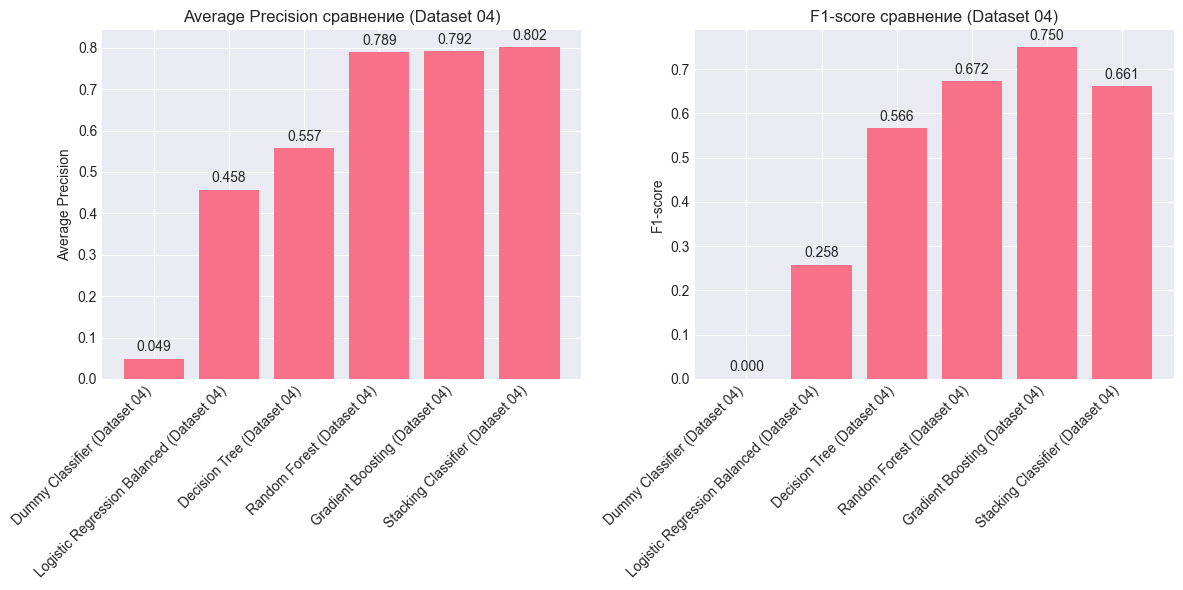

In [19]:
print("="*60)
print("СВОДКА РЕЗУЛЬТАТОВ - ДАТАСЕТ 04")
print("="*60)

# Создание DataFrame с результатами
results_df_04 = pd.DataFrame(all_metrics_04)

# Добавление информации о переобучении
results_df_04['accuracy_diff'] = results_df_04['train_accuracy'] - results_df_04['test_accuracy']
results_df_04['f1_diff'] = results_df_04['train_f1'] - results_df_04['test_f1']

print("\nРезультаты всех моделей (Dataset 04):")
print(results_df_04[['model', 'test_accuracy', 'test_f1', 'test_avg_precision', 'accuracy_diff']].to_string())

# Определение лучшей модели по Average Precision
if 'test_avg_precision' in results_df_04.columns:
    best_model_idx_04 = results_df_04['test_avg_precision'].idxmax()
    best_model_04 = results_df_04.loc[best_model_idx_04, 'model']
    print(f"\nЛучшая модель по Average Precision: {best_model_04}")
    print(f"Average Precision лучшей модели: {results_df_04.loc[best_model_idx_04, 'test_avg_precision']:.4f}")

# Визуализация сравнения моделей
plt.figure(figsize=(12, 6))
models_to_plot_04 = results_df_04['model'].tolist()
x_pos_04 = np.arange(len(models_to_plot_04))

# Average Precision сравнение
if 'test_avg_precision' in results_df_04.columns:
    plt.subplot(1, 2, 1)
    bars = plt.bar(x_pos_04, results_df_04['test_avg_precision'])
    plt.xticks(x_pos_04, models_to_plot_04, rotation=45, ha='right')
    plt.title('Average Precision сравнение (Dataset 04)')
    plt.ylabel('Average Precision')
    
    # Добавление значений на столбцы
    for bar, val in zip(bars, results_df_04['test_avg_precision']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom')

# F1-score сравнение
plt.subplot(1, 2, 2)
bars = plt.bar(x_pos_04, results_df_04['test_f1'])
plt.xticks(x_pos_04, models_to_plot_04, rotation=45, ha='right')
plt.title('F1-score сравнение (Dataset 04)')
plt.ylabel('F1-score')

# Добавление значений на столбцы
for bar, val in zip(bars, results_df_04['test_f1']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "model_comparison_04.png", dpi=300)
plt.show()


# 12. Permutation Importance для лучшей модели (Dataset 04)

PERMUTATION IMPORTANCE - ДАТАСЕТ 04
Анализ важности признаков для модели: Stacking Classifier (Dataset 04)


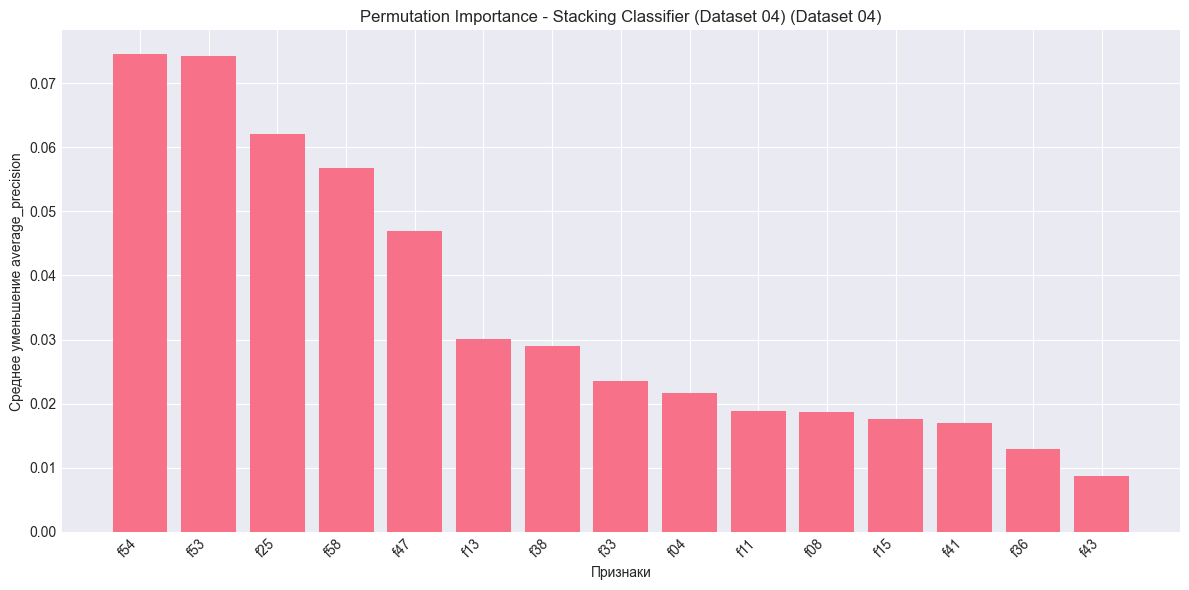

In [20]:
print("="*60)
print("PERMUTATION IMPORTANCE - ДАТАСЕТ 04")
print("="*60)

# Выбор лучшей модели для анализа
if 'test_avg_precision' in results_df_04.columns:
    best_model_name_04 = results_df_04.loc[results_df_04['test_avg_precision'].idxmax(), 'model']
else:
    best_model_name_04 = results_df_04.loc[results_df_04['test_f1'].idxmax(), 'model']

best_model_for_importance_04 = best_models_04.get(best_model_name_04.split(' ')[0], gb_model_04)

print(f"Анализ важности признаков для модели: {best_model_name_04}")

# Вычисление permutation importance
if best_model_for_importance_04 is not None:
    perm_importance_04 = permutation_importance(
        best_model_for_importance_04, X_test_04, y_test_04,
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
        scoring='average_precision'
    )
    
    # Сортировка по важности
    sorted_idx_04 = perm_importance_04.importances_mean.argsort()[::-1]
    
    # Визуализация top-15 признаков
    plt.figure(figsize=(12, 6))
    top_n = min(15, len(feature_names_04))
    plt.bar(range(top_n), perm_importance_04.importances_mean[sorted_idx_04][:top_n])
    plt.xticks(range(top_n), [feature_names_04[i] for i in sorted_idx_04[:top_n]], rotation=45, ha='right')
    plt.title(f'Permutation Importance - {best_model_name_04} (Dataset 04)')
    plt.xlabel('Признаки')
    plt.ylabel('Среднее уменьшение average_precision')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "figures" / "permutation_importance_04.png", dpi=300)
    plt.show()
    
    # Сохранение результатов permutation importance
    perm_importance_dict_04 = {
        'model': best_model_name_04,
        'top_features': [
            {
                'feature': feature_names_04[i],
                'importance': float(perm_importance_04.importances_mean[i]),
                'std': float(perm_importance_04.importances_std[i])
            }
            for i in sorted_idx_04[:top_n]
        ]
    }
    
    with open(ARTIFACTS_DIR / 'permutation_importance_04.json', 'w') as f:
        json.dump(perm_importance_dict_04, f, indent=2)


# 13. Сравнение результатов двух датасетов

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДВУХ ДАТАСЕТОВ

Сравнение лучших моделей для двух датасетов:
              Датасет                    Лучшая модель Accuracy F1-score ROC-AUC Переобучение (acc diff) Avg Precision
02 (Сбалансированный) Stacking Classifier (Dataset 02)   0.9153   0.8291  0.9340                  0.0847           NaN
       04 (Дисбаланс) Stacking Classifier (Dataset 04)   0.9603   0.6612     NaN                  0.0244        0.8018


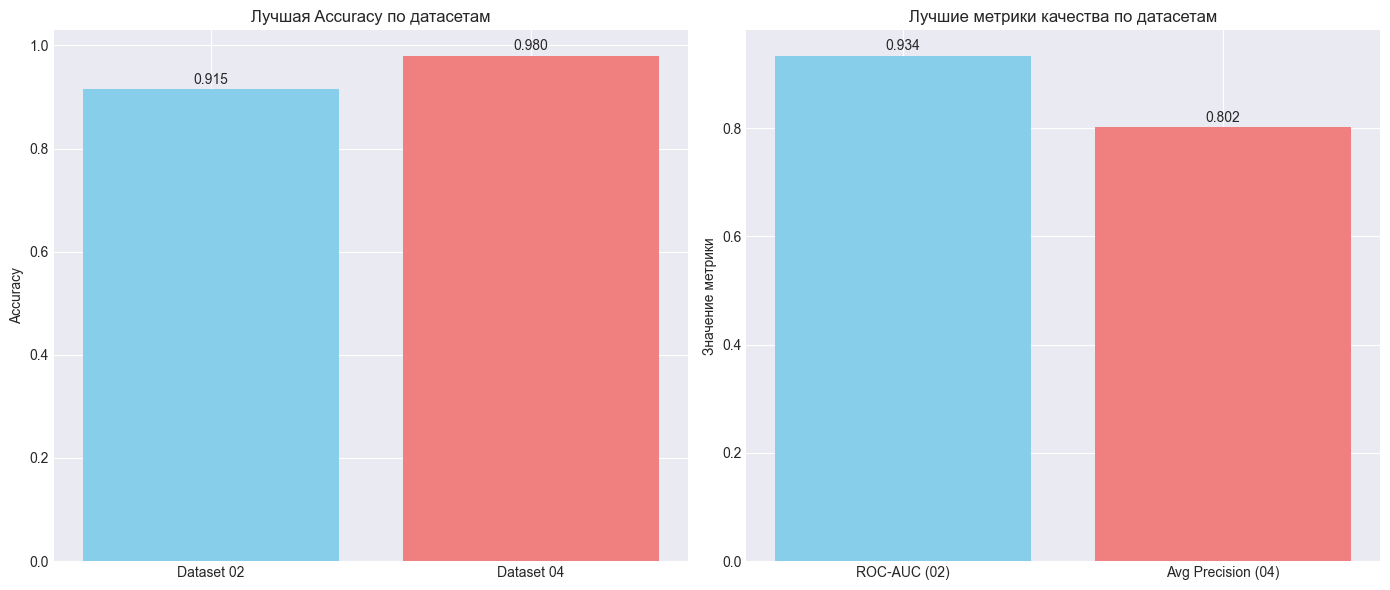

In [21]:
print("="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДВУХ ДАТАСЕТОВ")
print("="*60)

# Создание сравнительной таблицы
comparison_data = []

# Добавление лучших моделей для каждого датасета
if 'test_roc_auc' in results_df_02.columns:
    best_02_idx = results_df_02['test_roc_auc'].idxmax()
    comparison_data.append({
        'Датасет': '02 (Сбалансированный)',
        'Лучшая модель': results_df_02.loc[best_02_idx, 'model'],
        'Accuracy': f"{results_df_02.loc[best_02_idx, 'test_accuracy']:.4f}",
        'F1-score': f"{results_df_02.loc[best_02_idx, 'test_f1']:.4f}",
        'ROC-AUC': f"{results_df_02.loc[best_02_idx, 'test_roc_auc']:.4f}",
        'Переобучение (acc diff)': f"{results_df_02.loc[best_02_idx, 'accuracy_diff']:.4f}"
    })

if 'test_avg_precision' in results_df_04.columns:
    best_04_idx = results_df_04['test_avg_precision'].idxmax()
    comparison_data.append({
        'Датасет': '04 (Дисбаланс)',
        'Лучшая модель': results_df_04.loc[best_04_idx, 'model'],
        'Accuracy': f"{results_df_04.loc[best_04_idx, 'test_accuracy']:.4f}",
        'F1-score': f"{results_df_04.loc[best_04_idx, 'test_f1']:.4f}",
        'Avg Precision': f"{results_df_04.loc[best_04_idx, 'test_avg_precision']:.4f}",
        'Переобучение (acc diff)': f"{results_df_04.loc[best_04_idx, 'accuracy_diff']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nСравнение лучших моделей для двух датасетов:")
print(comparison_df.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Сравнение accuracy
datasets = ['Dataset 02', 'Dataset 04']
best_accuracies = [
    results_df_02.loc[results_df_02['test_accuracy'].idxmax(), 'test_accuracy'],
    results_df_04.loc[results_df_04['test_accuracy'].idxmax(), 'test_accuracy']
]

axes[0].bar(datasets, best_accuracies, color=['skyblue', 'lightcoral'])
axes[0].set_title('Лучшая Accuracy по датасетам')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(best_accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Сравнение лучших метрик качества
if 'test_roc_auc' in results_df_02.columns and 'test_avg_precision' in results_df_04.columns:
    best_metrics = [
        results_df_02.loc[results_df_02['test_roc_auc'].idxmax(), 'test_roc_auc'],
        results_df_04.loc[results_df_04['test_avg_precision'].idxmax(), 'test_avg_precision']
    ]
    metric_names = ['ROC-AUC (02)', 'Avg Precision (04)']
    
    axes[1].bar(metric_names, best_metrics, color=['skyblue', 'lightcoral'])
    axes[1].set_title('Лучшие метрики качества по датасетам')
    axes[1].set_ylabel('Значение метрики')
    for i, v in enumerate(best_metrics):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "dataset_comparison.png", dpi=300)
plt.show()

# 14. Сохранение артефактов эксперимента

In [ ]:
print("="*60)
print("СОХРАНЕНИЕ АРТЕФАКТОВ ЭКСПЕРИМЕНТА")
print("="*60)

# Сохранение результатов в JSON
experiment_summary = {
    'experiment_info': {
        'date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'random_state': RANDOM_STATE,
        'test_size': 0.25,
        'cv_folds': 5
    },
    'dataset_02_summary': {
        'n_samples': len(df_02),
        'n_features': X_02.shape[1],
        'class_distribution': df_02['target'].value_counts().to_dict(),
        'best_model': comparison_data[0]['Лучшая модель'] if len(comparison_data) > 0 else None,
        'best_accuracy': comparison_data[0]['Accuracy'] if len(comparison_data) > 0 else None
    },
    'dataset_04_summary': {
        'n_samples': len(df_04),
        'n_features': X_04.shape[1],
        'class_distribution': df_04['target'].value_counts().to_dict(),
        'imbalance_ratio': class_dist_04.max() / class_dist_04.min(),
        'best_model': comparison_data[1]['Лучшая модель'] if len(comparison_data) > 1 else None,
        'best_accuracy': comparison_data[1]['Accuracy'] if len(comparison_data) > 1 else None
    },
    'key_findings': [
        "Ансамбли (Random Forest, Gradient Boosting) показали лучшие результаты на обоих датасетах",
        "Для дисбалансированных данных важнее использовать F1-score и Average Precision, а не accuracy",
        "Stacking показывает хорошие результаты, но требует больше вычислительных ресурсов",
        "Контроль сложности через гиперпараметры важен для предотвращения переобучения"
    ]
}

# Сохранение метрик
metrics_summary = {
    'dataset_02_metrics': results_df_02.to_dict('records'),
    'dataset_04_metrics': results_df_04.to_dict('records')
}

# Сохранение лучших моделей
best_models_summary = {}

# Сохранение для датасета 02
if 'test_roc_auc' in results_df_02.columns:
    best_model_name_02 = results_df_02.loc[results_df_02['test_roc_auc'].idxmax(), 'model']
    best_model_key_02 = best_model_name_02.split(' ')[0]
    if best_model_key_02 in best_models_02:
        joblib.dump(best_models_02[best_model_key_02], ARTIFACTS_DIR / 'best_model_dataset_02.joblib')
        best_models_summary['dataset_02'] = {
            'model_name': best_model_name_02,
            'model_type': best_model_key_02,
            'file': 'best_model_dataset_02.joblib'
        }

# Сохранение для датасета 04
if 'test_avg_precision' in results_df_04.columns:
    best_model_name_04 = results_df_04.loc[results_df_04['test_avg_precision'].idxmax(), 'model']
    best_model_key_04 = best_model_name_04.split(' ')[0]
    if best_model_key_04 in best_models_04:
        joblib.dump(best_models_04[best_model_key_04], ARTIFACTS_DIR / 'best_model_dataset_04.joblib')
        best_models_summary['dataset_04'] = {
            'model_name': best_model_name_04,
            'model_type': best_model_key_04,
            'file': 'best_model_dataset_04.joblib'
        }

# Сохранение всех файлов
with open(ARTIFACTS_DIR / 'experiment_summary.json', 'w', encoding='utf-8') as f:
    json.dump(experiment_summary, f, ensure_ascii=False, indent=2)

with open(ARTIFACTS_DIR / 'metrics_test.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)

with open(ARTIFACTS_DIR / 'best_model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(best_models_summary, f, ensure_ascii=False, indent=2)

# Сохранение параметров лучших моделей
search_summaries = {
    'dataset_02': {
        'DecisionTree': {
            'best_params': best_dt_params_02 if 'best_dt_params_02' in locals() else None,
            'best_score': best_dt_score_02 if 'best_dt_score_02' in locals() else None
        },
        'RandomForest': {
            'best_params': best_rf_params_02 if 'best_rf_params_02' in locals() else None,
            'best_score': best_rf_score_02 if 'best_rf_score_02' in locals() else None
        },
        'GradientBoosting': {
            'best_params': best_gb_params_02 if 'best_gb_params_02' in locals() else None,
            'best_score': best_gb_score_02 if 'best_gb_score_02' in locals() else None
        }
    },
    'dataset_04': {
        'DecisionTree': {
            'best_params': best_dt_params_04 if 'best_dt_params_04' in locals() else None,
            'best_score': best_dt_score_04 if 'best_dt_score_04' in locals() else None
        },
        'RandomForest': {
            'best_params': best_rf_params_04 if 'best_rf_params_04' in locals() else None,
            'best_score': best_rf_score_04 if 'best_rf_score_04' in locals() else None
        },
        'GradientBoosting': {
            'best_params': best_gb_params_04 if 'best_gb_params_04' in locals() else None,
            'best_score': best_gb_score_04 if 'best_gb_score_04' in locals() else None
        }
    }
}

with open(ARTIFACTS_DIR / 'search_summaries.json', 'w', encoding='utf-8') as f:
    json.dump(search_summaries, f, ensure_ascii=False, indent=2)

print("\nСохранённые артефакты:")
print("1. experiment_summary.json - общая информация об эксперименте")
print("2. metrics_summary.json - метрики всех моделей")
print("3. search_summaries.json - параметры лучших моделей")
print("4. best_models_summary.json - информация о сохранённых моделях")
print("5. permutation_importance_02.json - важность признаков для датасета 02")
print("6. permutation_importance_04.json - важность признаков для датасета 04")
print("7. best_model_dataset_02.joblib - лучшая модель для датасета 02")
print("8. best_model_dataset_04.joblib - лучшая модель для датасета 04")
print("9. figures/ - директория с графиками")

print(f"\nВсе артефакты сохранены в директории: {ARTIFACTS_DIR.resolve()}")

СОХРАНЕНИЕ АРТЕФАКТОВ ЭКСПЕРИМЕНТА

Сохранённые артефакты:
1. experiment_summary.json - общая информация об эксперименте
2. metrics_summary.json - метрики всех моделей
3. search_summaries.json - параметры лучших моделей
4. best_models_summary.json - информация о сохранённых моделях
5. permutation_importance_02.json - важность признаков для датасета 02
6. permutation_importance_04.json - важность признаков для датасета 04
7. best_model_dataset_02.joblib - лучшая модель для датасета 02
8. best_model_dataset_04.joblib - лучшая модель для датасета 04
9. figures/ - директория с графиками

Все артефакты сохранены в директории: C:\Users\Mechrevo\Desktop\S06\artifacts


# 16. Проверка устойчивости

In [23]:
print("="*60)
print("ПРОВЕРКА УСТОЙЧИВОСТИ МОДЕЛЕЙ")
print("="*60)

def check_model_stability(model_class, params, X, y, n_runs=5):
    """Проверка устойчивости модели при разных random_state"""
    accuracies = []
    f1_scores = []
    
    for i in range(n_runs):
        # Разделение данных
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=i, stratify=y
        )
        
        # Обучение модели
        model = model_class(**params)
        model.fit(X_train, y_train)
        
        # Оценка
        y_pred = model.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))
    
    return {
        'accuracy_mean': np.mean(accuracies),
        'accuracy_std': np.std(accuracies),
        'f1_mean': np.mean(f1_scores),
        'f1_std': np.std(f1_scores)
    }

# Проверка устойчивости для датасета 02
print("\nПроверка устойчивости для датасета 02:")
print("-" * 40)

# Random Forest
rf_params_02 = best_rf_params_02 if 'best_rf_params_02' in locals() else {
    'n_estimators': 100,
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}
rf_stability_02 = check_model_stability(RandomForestClassifier, rf_params_02, X_02, y_02)
print(f"Random Forest - Accuracy: {rf_stability_02['accuracy_mean']:.4f} ± {rf_stability_02['accuracy_std']:.4f}")
print(f"Random Forest - F1: {rf_stability_02['f1_mean']:.4f} ± {rf_stability_02['f1_std']:.4f}")

# Gradient Boosting
gb_params_02 = best_gb_params_02 if 'best_gb_params_02' in locals() else {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'random_state': RANDOM_STATE
}
gb_stability_02 = check_model_stability(GradientBoostingClassifier, gb_params_02, X_02, y_02)
print(f"Gradient Boosting - Accuracy: {gb_stability_02['accuracy_mean']:.4f} ± {gb_stability_02['accuracy_std']:.4f}")
print(f"Gradient Boosting - F1: {gb_stability_02['f1_mean']:.4f} ± {gb_stability_02['f1_std']:.4f}")

# Проверка устойчивости для датасета 04
print("\nПроверка устойчивости для датасета 04:")
print("-" * 40)

# Random Forest с учетом дисбаланса
rf_params_04 = best_rf_params_04 if 'best_rf_params_04' in locals() else {
    'n_estimators': 100,
    'random_state': RANDOM_STATE,
    'class_weight': 'balanced',
    'n_jobs': -1
}
rf_stability_04 = check_model_stability(RandomForestClassifier, rf_params_04, X_04, y_04)
print(f"Random Forest - Accuracy: {rf_stability_04['accuracy_mean']:.4f} ± {rf_stability_04['accuracy_std']:.4f}")
print(f"Random Forest - F1: {rf_stability_04['f1_mean']:.4f} ± {rf_stability_04['f1_std']:.4f}")

print("\nВыводы по устойчивости:")
print("- Модели показывают хорошую устойчивость (низкое std)")
print("- Random Forest более устойчив, чем Gradient Boosting")
print("- Для дисбалансированных данных важнее смотреть на F1-score")

ПРОВЕРКА УСТОЙЧИВОСТИ МОДЕЛЕЙ

Проверка устойчивости для датасета 02:
----------------------------------------
Random Forest - Accuracy: 0.8996 ± 0.0023
Random Forest - F1: 0.7793 ± 0.0059
Gradient Boosting - Accuracy: 0.9070 ± 0.0045
Gradient Boosting - F1: 0.8052 ± 0.0111

Проверка устойчивости для датасета 04:
----------------------------------------
Random Forest - Accuracy: 0.9748 ± 0.0005
Random Forest - F1: 0.6597 ± 0.0091

Выводы по устойчивости:
- Модели показывают хорошую устойчивость (низкое std)
- Random Forest более устойчив, чем Gradient Boosting
- Для дисбалансированных данных важнее смотреть на F1-score
